In [12]:
# =============================================
# IMPORTY
# =============================================
import os
import sys
import math

import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f"✓ Device: {device}")
print(f"✓ PyTorch: {torch.__version__}")

# Nastav working directory na kořen projektu
_nb_dir = os.path.abspath('')
if os.path.basename(_nb_dir) in ('experiments', 'examples', 'train'):
    os.chdir(os.path.dirname(_nb_dir))
sys.path.insert(0, os.path.join(os.getcwd(), 'PFNs'))
print(f"✓ Working directory: {os.getcwd()}")
# PFNs — musí být naklonováno (viz setup.sh)
from pfns.train import train, MainConfig, OptimizerConfig, TransformerConfig, BatchShapeSamplerConfig
from pfns.model.encoders import EncoderConfig
from pfns.model.bar_distribution import BarDistributionConfig
from pfns.priors.prior import AdhocPriorConfig
from pfns.priors.fast_gp import get_batch as get_batch_for_gp

print("✓ PFNs načteny")

✓ Device: mps
✓ PyTorch: 2.10.0
✓ Working directory: /Users/ruslanguliev/VU_RG
✓ PFNs načteny


In [13]:
# =============================================
# LOAD HELPER — funguje pro oba formáty checkpointů
# =============================================

def load_pfn_model(checkpoint_path, device='cpu'):
    """
    Načte PFN model z checkpointu.
    Podporuje oba formáty:
      - novější (MainConfig dict, saved from epoch loop)
      - starší (simple hps dict, saved from train_gp_pfn())
    Vrací: (model, hps, epoch)
    """
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"Model nenalezen: {checkpoint_path}\n"
            "Nejdřív natrénuj model v train/PFN_TRAIN_SETUP.ipynb"
        )

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    config_data = checkpoint.get('config', {})

    if isinstance(config_data, dict) and 'priors' in config_data:
        saved_config = MainConfig.from_dict(config_data)
        model = saved_config.model.create_model()
        model.load_state_dict(checkpoint['model_state_dict'])
        hps = saved_config.priors[0].prior_kwargs['hyperparameters']
        epoch = checkpoint.get('epoch', '?')

    elif isinstance(config_data, dict) and 'hps' in config_data:
        hps = config_data['hps']
        epoch = config_data.get('epochs', checkpoint.get('epoch', '?'))
        criterion = checkpoint['criterion']
        cfg = MainConfig(
            priors=[AdhocPriorConfig(
                get_batch_methods=[get_batch_for_gp],
                prior_kwargs={'num_features': 1, 'hyperparameters': hps}
            )],
            optimizer=OptimizerConfig('adamw', lr=0.0003),
            model=TransformerConfig(
                criterion=BarDistributionConfig(
                    full_support=True,
                    borders=criterion.borders.tolist()
                ),
                emsize=512, nhead=8, nhid=1024, nlayers=6,
                features_per_group=1,
                attention_between_features=False,
                encoder=EncoderConfig(
                    constant_normalization_mean=0.5,
                    constant_normalization_std=math.sqrt(1/12)
                )
            ),
            batch_shape_sampler=BatchShapeSamplerConfig(
                batch_size=64, max_seq_len=50,
                min_num_features=1, max_num_features=1
            ),
            epochs=20, warmup_epochs=5,
            steps_per_epoch=100, num_workers=0,
        )
        model = cfg.model.create_model()
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        raise ValueError(f"Neznámý formát checkpointu. Klíče: {list(config_data.keys())}")

    model.to(device)
    model.eval()
    return model, hps, epoch

print("✓ load_pfn_model připraven")


✓ load_pfn_model připraven


In [14]:
# =============================================
# NAČTENÍ MODELU
# =============================================

checkpoint_path = os.path.join('models', 'pfn_latest_epoch_100.pth')
loaded_model, hps, epoch = load_pfn_model(checkpoint_path, device)

print(f'✓ Model načten (epocha {epoch})')
print(f'  GP params: {hps}')
print(f'  Parametrů: {sum(p.numel() for p in loaded_model.parameters()) / 1e6:.2f}M')


Using linear y encoder, as no y_encoder was provided.
✓ Model načten (epocha 100)
  GP params: {'noise': 0.0001, 'outputscale': 1.0, 'lengthscale': 0.3}
  Parametrů: 14.14M


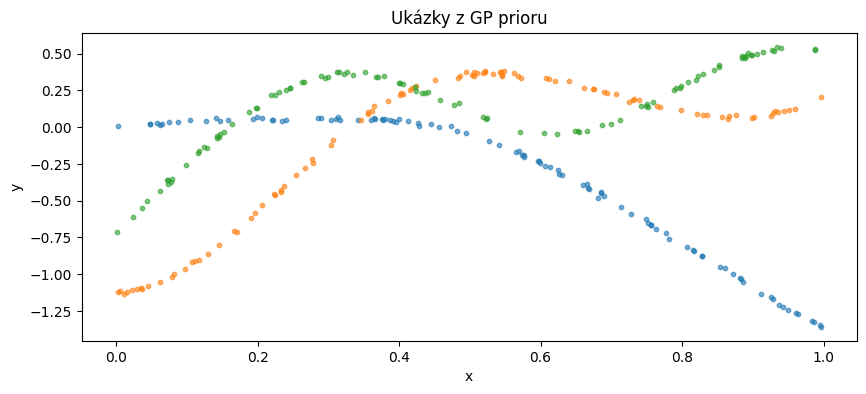

Batch shapes: x=torch.Size([3, 100, 1]), y=torch.Size([3, 100])


In [15]:
# =============================================
# GP PRIOR - Sampling funkce
# =============================================

# Ukázka dat z GP prioru
batch = get_batch_for_gp(batch_size=3, seq_len=100, num_features=1, hyperparameters=hps)

plt.figure(figsize=(10, 4))
for i in range(len(batch.x)):
    plt.scatter(batch.x[i, :, 0].cpu().numpy(), batch.y[i, :].cpu().numpy(), alpha=0.6, s=10)
plt.title('Ukázky z GP prioru')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

print(f"Batch shapes: x={batch.x.shape}, y={batch.y.shape}")

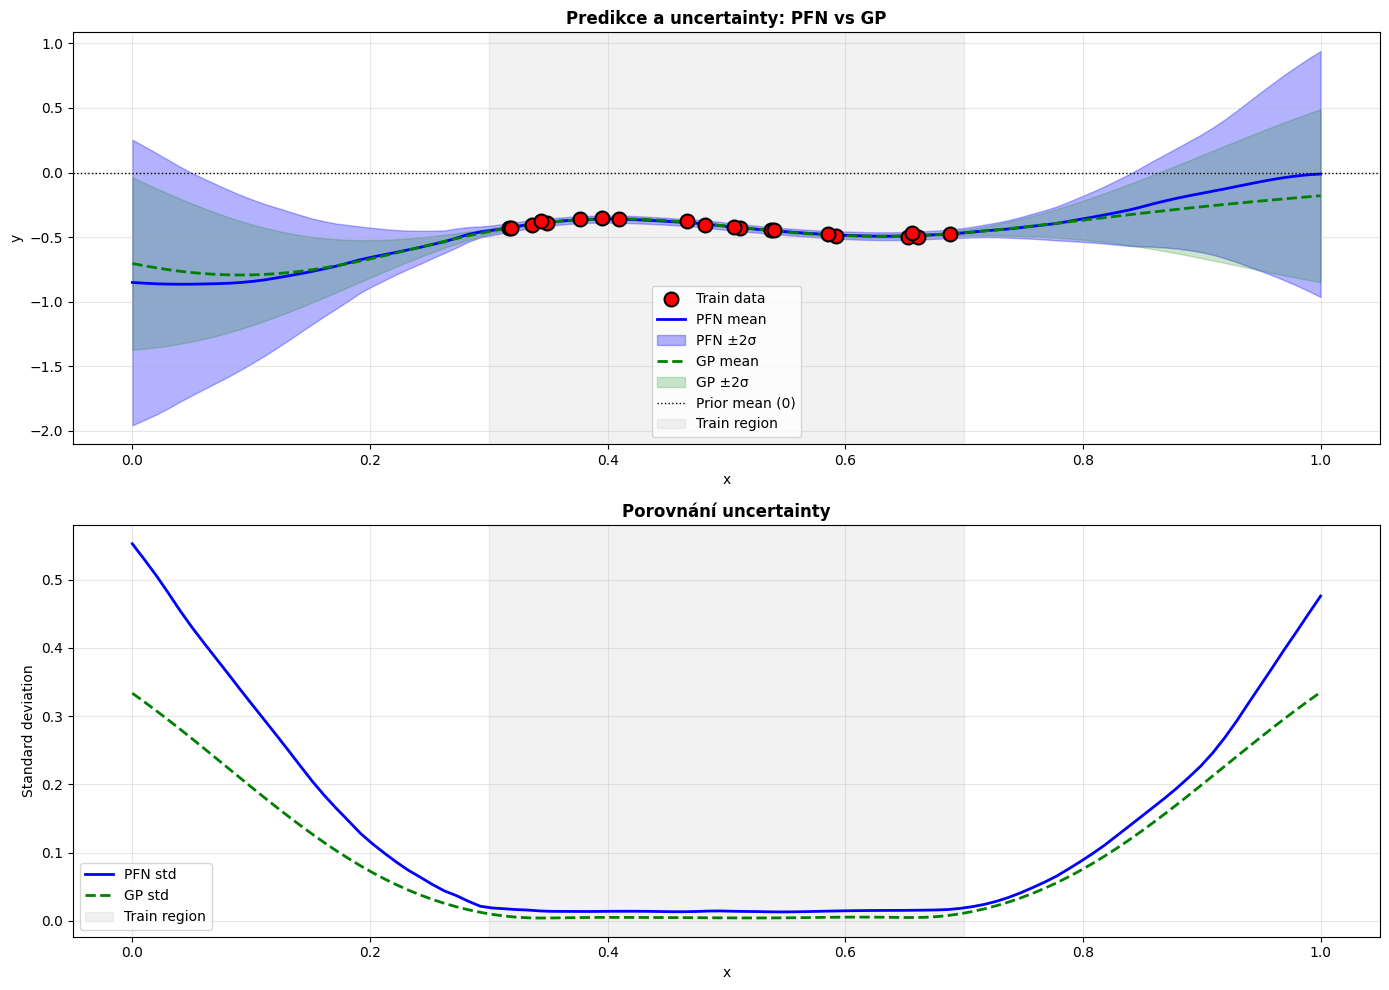


=== TEST 1: Konvergence mean funkce ===
Trial 0:
  Train data mean: -0.43
  PFN mean (far): -0.49, (near): -0.42
  GP mean (far):  -0.51, (near): -0.42
  PFN converges to train mean: True
  GP converges to train mean:  True
Trial 1:
  Train data mean: 0.53
  PFN mean (far): 0.19, (near): 0.68
  GP mean (far):  0.23, (near): 0.68
  PFN converges to train mean: True
  GP converges to train mean:  True
Trial 2:
  Train data mean: -1.65
  PFN mean (far): 0.01, (near): -1.91
  GP mean (far):  0.13, (near): -1.91
  PFN converges to train mean: False
  GP converges to train mean:  False
Trial 3:
  Train data mean: -0.59
  PFN mean (far): -1.30, (near): -0.44
  GP mean (far):  -1.19, (near): -0.44
  PFN converges to train mean: True
  GP converges to train mean:  True
Trial 4:
  Train data mean: 1.20
  PFN mean (far): 1.07, (near): 1.09
  GP mean (far):  1.09, (near): 1.09
  PFN converges to train mean: True
  GP converges to train mean:  True

=== TEST 2: Správnost variance ===
Trial 0:
  Co

In [16]:
# =============================================
# EXPERIMENT 1: Konvergence k prioru a variance
# =============================================

def test_prior_convergence_and_variance(model, hps, n_trials=10):
    results = []

    for trial in range(n_trials):
        torch.seed()
        np.random.seed()
        batch = get_batch_for_gp(batch_size=1, seq_len=100, num_features=1, hyperparameters=hps)

        train_mask = (batch.x[0, :, 0] >= 0.3) & (batch.x[0, :, 0] <= 0.7)
        train_indices = torch.where(train_mask)[0][:20]

        train_x = batch.x[0, train_indices]
        train_y = batch.y[0, train_indices]

        test_x = torch.linspace(0, 1, 100).unsqueeze(1).to(batch.x.device)

        # PFN predikce
        with torch.no_grad():
            logits = model(train_x[None], train_y[None], test_x[None])

        pfn_means = model.criterion.mean(logits)[0].cpu().numpy()
        pfn_variance = model.criterion.variance(logits)[0].cpu().numpy()
        pfn_std = np.sqrt(pfn_variance)

        # GP predikce
        from sklearn.gaussian_process import GaussianProcessRegressor
        from sklearn.gaussian_process.kernels import RBF, ConstantKernel

        kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=hps['lengthscale'])
        gp = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
        gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
        gp_mean, gp_std = gp.predict(test_x.cpu().numpy(), return_std=True)

        results.append({
            'test_x': test_x.cpu().numpy().flatten(),
            'train_x': train_x.cpu().numpy().flatten(),
            'train_y': train_y.cpu().numpy().flatten(), 
            'pfn_mean': pfn_means,
            'pfn_std': pfn_std,
            'gp_mean': gp_mean,
            'gp_std': gp_std,
        })

    return results


# Spusť test
results = test_prior_convergence_and_variance(loaded_model, hps, n_trials=5)

# Vizualizace jednoho příkladu
res = results[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Mean + uncertainty bands
ax = axes[0]

# Train data
ax.scatter(res['train_x'], res['train_y'],
           c='red', s=100, zorder=10, label='Train data', marker='o', edgecolors='black', linewidths=1.5)

# PFN prediction
ax.plot(res['test_x'], res['pfn_mean'], 'b-', lw=2, label='PFN mean')
ax.fill_between(res['test_x'],
                 res['pfn_mean'] - 2*res['pfn_std'],
                 res['pfn_mean'] + 2*res['pfn_std'],
                 alpha=0.3, color='blue', label='PFN ±2σ')

# GP prediction
ax.plot(res['test_x'], res['gp_mean'], 'g--', lw=2, label='GP mean')
ax.fill_between(res['test_x'],
                 res['gp_mean'] - 2*res['gp_std'],
                 res['gp_mean'] + 2*res['gp_std'],
                 alpha=0.2, color='green', label='GP ±2σ')

# Prior mean (0)
ax.axhline(y=0, color='black', linestyle=':', lw=1, label='Prior mean (0)')

# Zvýrazni train region
ax.axvspan(0.3, 0.7, alpha=0.1, color='gray', label='Train region')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Predikce a uncertainty: PFN vs GP', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Comparison of uncertainties
ax = axes[1]

ax.plot(res['test_x'], res['pfn_std'], 'b-', lw=2, label='PFN std')
ax.plot(res['test_x'], res['gp_std'], 'g--', lw=2, label='GP std')
ax.axvspan(0.3, 0.7, alpha=0.1, color='gray', label='Train region')

ax.set_xlabel('x')
ax.set_ylabel('Standard deviation')
ax.set_title('Porovnání uncertainty', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# === KVANTITATIVNÍ TESTY ===

print("\n=== TEST 1: Konvergence mean funkce ===")
for i, res in enumerate(results):
    far_mask = (res['test_x'] < 0.2) | (res['test_x'] > 0.8)
    near_mask = (res['test_x'] >= 0.4) & (res['test_x'] <= 0.6)

    # Mean hodnoty daleko vs blízko
    pfn_mean_far = np.mean(res['pfn_mean'][far_mask])
    pfn_mean_near = np.mean(res['pfn_mean'][near_mask])
    gp_mean_far = np.mean(res['gp_mean'][far_mask])
    gp_mean_near = np.mean(res['gp_mean'][near_mask])

    # Empirický mean z train dat
    train_mean = np.mean(res['train_y'])

    print(f"Trial {i}:")
    print(f"  Train data mean: {train_mean:.2f}")
    print(f"  PFN mean (far): {pfn_mean_far:.2f}, (near): {pfn_mean_near:.2f}")
    print(f"  GP mean (far):  {gp_mean_far:.2f}, (near): {gp_mean_near:.2f}")
    print(f"  PFN converges to train mean: {abs(pfn_mean_far - train_mean) < 1.0}")
    print(f"  GP converges to train mean:  {abs(gp_mean_far - train_mean) < 1.0}")

print("\n=== TEST 2: Správnost variance ===")
for i, res in enumerate(results):
    # Korelace mezi PFN a GP std
    corr = np.corrcoef(res['pfn_std'], res['gp_std'])[0, 1]

    # MSE mezi std
    mse_std = np.mean((res['pfn_std'] - res['gp_std'])**2)

    # Poměr std daleko vs blízko
    far_mask = (res['test_x'] < 0.2) | (res['test_x'] > 0.8)
    near_mask = (res['test_x'] >= 0.4) & (res['test_x'] <= 0.6)

    pfn_ratio = np.mean(res['pfn_std'][far_mask]) / np.mean(res['pfn_std'][near_mask])
    gp_ratio = np.mean(res['gp_std'][far_mask]) / np.mean(res['gp_std'][near_mask])

    print(f"Trial {i}:")
    print(f"  Correlation PFN vs GP std: {corr:.4f}")
    print(f"  MSE(PFN std, GP std): {mse_std:.6f}")
    print(f"  PFN uncertainty ratio (far/near): {pfn_ratio:.2f}")
    print(f"  GP uncertainty ratio (far/near): {gp_ratio:.2f}")

# Interpretace



*   Je vidět, že MSE GP vs PFN je mnohem nižší pro větší model, což dává dobrý smysl. Aproximaci je lze zlepšovat delším tréninkem.

*   Uncertainty ratio se podařilo taky zlepšit, ale stále jsou konfidenční intervaly u GP mnohem lepší pro outliery než u PFN, ale i tento parametr se podařilo vylepšit delším tréninkem.





In [17]:
# =============================================
# DATASET — spusť pro nová náhodná data
# =============================================
# Stačí spustit tuto buňku — model se znovu nenačítá
# Sdílený batch pro Experimenty 2–11

torch.seed()
np.random.seed()

n_context = 20
seq_len = 100

batch = get_batch_for_gp(batch_size=1, seq_len=seq_len, num_features=1, hyperparameters=hps)
train_x = batch.x[0, :n_context]     # [n_context, 1]
train_y = batch.y[0, :n_context]     # [n_context]
test_x  = batch.x[0]                 # [seq_len, 1]

print(f"Nový dataset: {n_context} train bodů, {seq_len - n_context} test bodů")

Nový dataset: 20 train bodů, 80 test bodů


Počet vrstev: 6
Vrstva 0: attention shape = torch.Size([1, 1, 8, 120, 120])
Vrstva 1: attention shape = torch.Size([1, 1, 8, 120, 120])
Vrstva 2: attention shape = torch.Size([1, 1, 8, 120, 120])
Vrstva 3: attention shape = torch.Size([1, 1, 8, 120, 120])
Vrstva 4: attention shape = torch.Size([1, 1, 8, 120, 120])
Vrstva 5: attention shape = torch.Size([1, 1, 8, 120, 120])


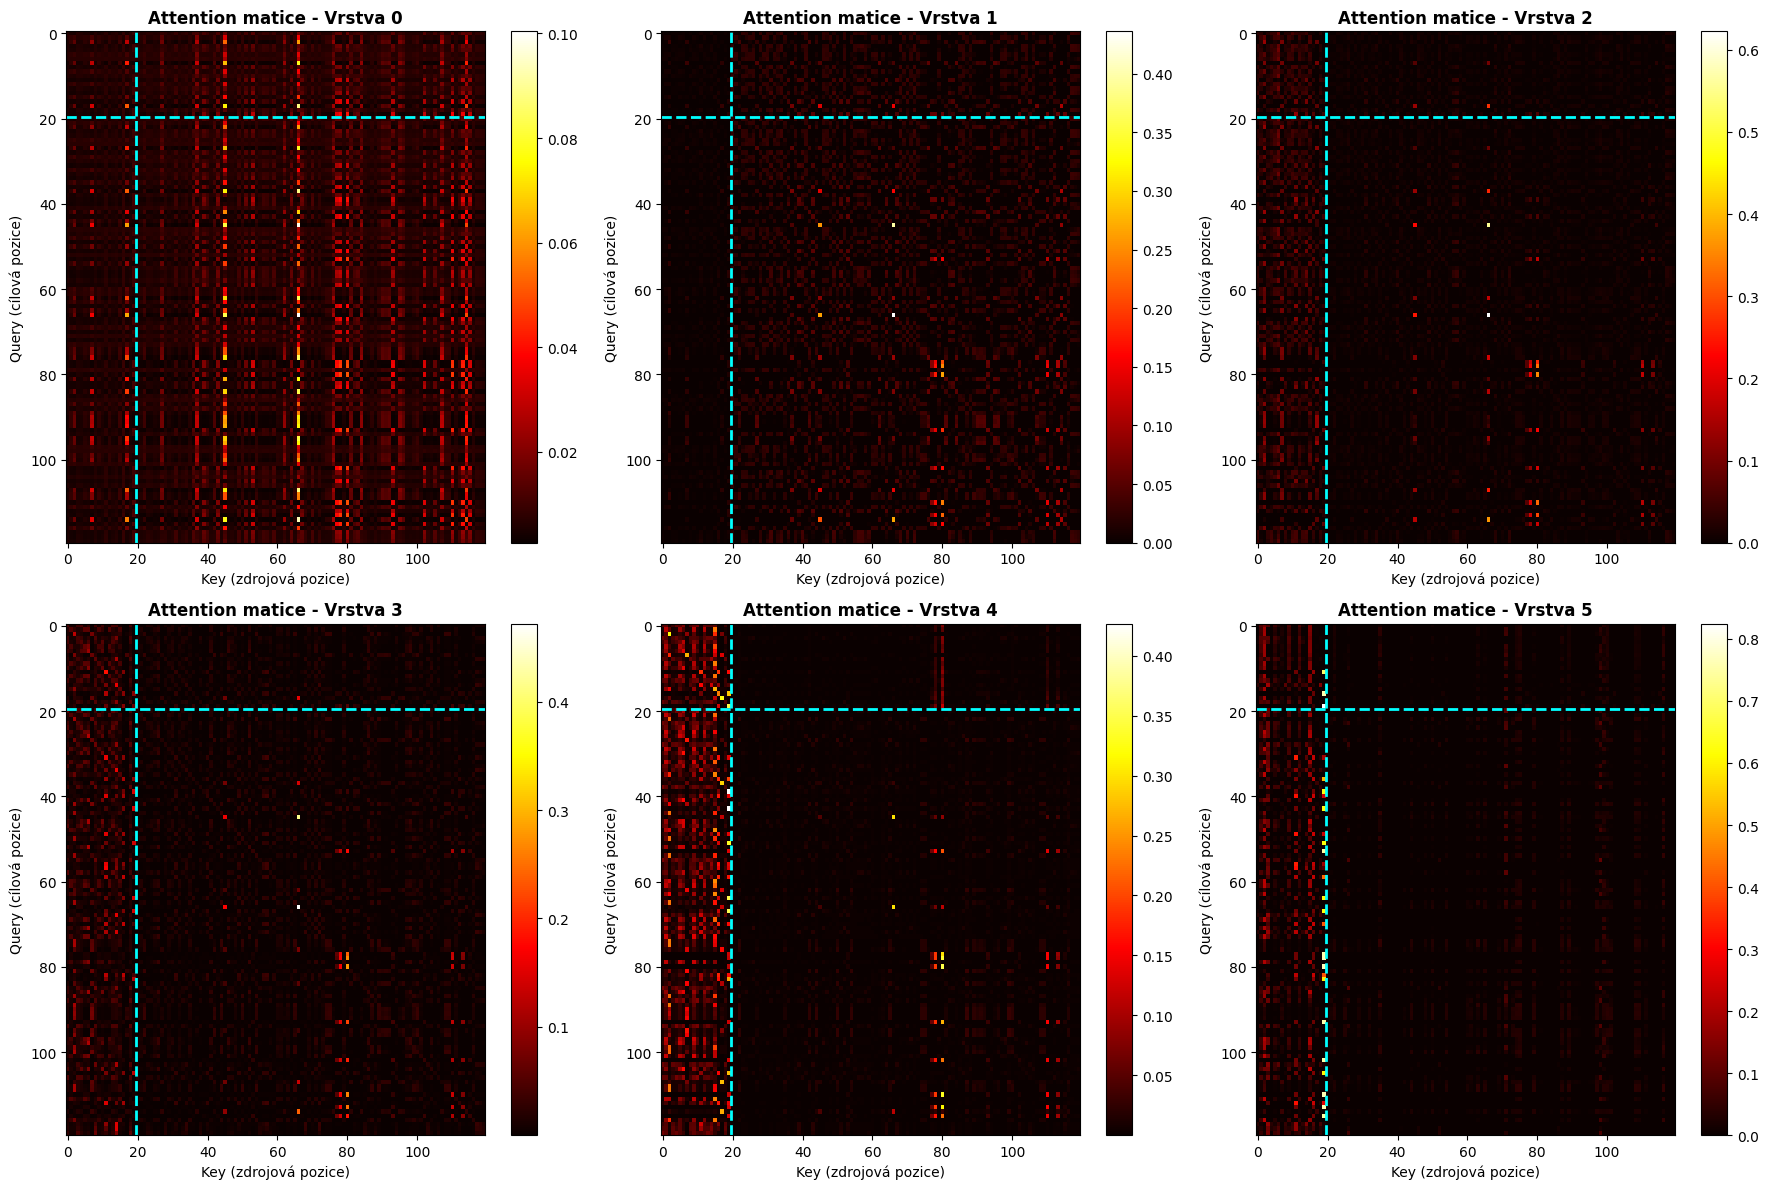

In [18]:
# =============================================
# EXPERIMENT 2: Zkoumání Attention vah
# =============================================
import torch.nn.functional as F

def compute_attention_weights(model, train_x, train_y, test_x):
    """
    Zachytí vstupy do attention a manuálně vypočítá attention váhy.
    """
    model.eval()

    layer_inputs = []

    def input_hook(module, inputs, output):
        layer_inputs.append(inputs[0].detach().cpu())

    # Hook na attention vrstvy
    hooks = []
    attn_modules = []
    for name, module in model.named_modules():
        if 'self_attn_between_items' in name and 'self_attn_between_items.' not in name:
            hooks.append(module.register_forward_hook(input_hook))
            attn_modules.append(module)

    with torch.no_grad():
        _ = model(train_x[None], train_y[None], test_x[None])

    for hook in hooks:
        hook.remove()

    # Vypočítej attention váhy pro každou vrstvu
    all_attention_weights = []

    for layer_idx, module in enumerate(attn_modules):
        if layer_idx >= len(layer_inputs):
            break

        x = layer_inputs[layer_idx]
        w_qkv = module.w_qkv.cpu()

        batch, features, seq_len, embed_dim = x.shape
        n_heads = w_qkv.shape[1]
        head_dim = w_qkv.shape[2]

        x_flat = x.reshape(-1, embed_dim)

        W_q = w_qkv[0]
        W_k = w_qkv[1]

        W_q_t = W_q.permute(2, 0, 1)
        W_k_t = W_k.permute(2, 0, 1)

        Q = torch.matmul(x_flat, W_q_t.reshape(embed_dim, -1)).reshape(-1, n_heads, head_dim)
        K = torch.matmul(x_flat, W_k_t.reshape(embed_dim, -1)).reshape(-1, n_heads, head_dim)

        Q = Q.reshape(batch, features, seq_len, n_heads, head_dim)
        K = K.reshape(batch, features, seq_len, n_heads, head_dim)

        Q = Q.permute(0, 1, 3, 2, 4)
        K = K.permute(0, 1, 3, 2, 4)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (head_dim ** 0.5)
        attn_weights = F.softmax(scores, dim=-1)

        all_attention_weights.append(attn_weights)

    return all_attention_weights, layer_inputs

# Použije globální train_x, train_y, test_x z buňky DATASET
attn_weights, layer_inputs = compute_attention_weights(loaded_model, train_x, train_y, test_x)

print(f"Počet vrstev: {len(attn_weights)}")
for i, w in enumerate(attn_weights):
    print(f"Vrstva {i}: attention shape = {w.shape}")



fig1, axes1 = plt.subplots(2, 3, figsize=(18, 12))
axes1 = axes1.flatten()

for layer_idx in range(6):
    # Průměr přes všechny heads
    attn_layer = attn_weights[layer_idx][0, 0].mean(dim=0).detach().numpy()  # [seq_len, seq_len]

    ax = axes1[layer_idx]
    im = ax.imshow(attn_layer, cmap='hot', aspect='auto')
    ax.axhline(y=n_context-0.5, color='cyan', linestyle='--', lw=2)
    ax.axvline(x=n_context-0.5, color='cyan', linestyle='--', lw=2)
    ax.set_xlabel('Key (zdrojová pozice)')
    ax.set_ylabel('Query (cílová pozice)')
    ax.set_title(f'Attention matice - Vrstva {layer_idx}', fontweight='bold')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Interpretace

  * Zde můžeme pozorovat, že pro větší model je struktura Attention matic více méně stejná.

  * Jediným zlepšením může být, že patterny v poslední matici jsou mnohem čistší než pro malý model, což opět dává dobrý smysl: delší trénink -> přesnější prokladání křikvkou.


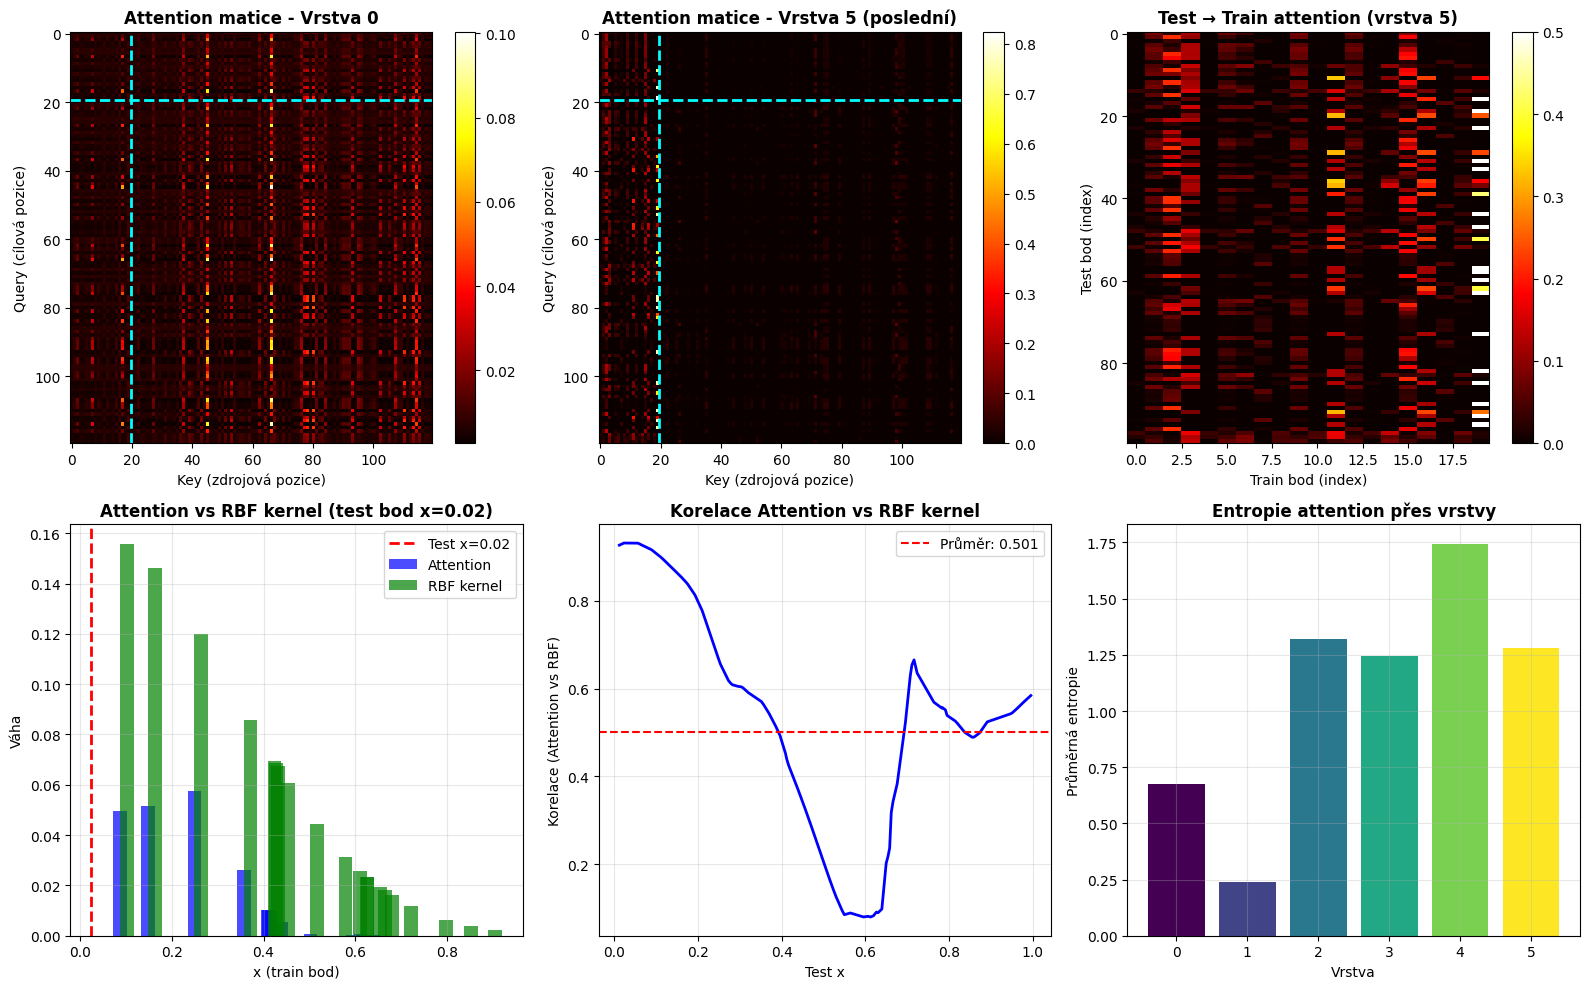


Průměrná korelace Attention vs RBF: 0.5008
Vyšší korelace = PFN se naučil kernel-like chování


In [ ]:
# Průměr přes všechny heads
attn_layer0 = attn_weights[0][0, 0].mean(dim=0).detach().numpy()  # [70, 70]
attn_layer5 = attn_weights[5][0, 0].mean(dim=0).detach().numpy()  # [70, 70]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Attention matice - vrstva 0
ax = axes[0, 0]
im = ax.imshow(attn_layer0, cmap='hot', aspect='auto')
ax.axhline(y=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.axvline(x=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.set_xlabel('Key (zdrojová pozice)')
ax.set_ylabel('Query (cílová pozice)')
ax.set_title('Attention matice - Vrstva 0', fontweight='bold')
plt.colorbar(im, ax=ax)

# 2. Attention matice - vrstva 5 (poslední)
ax = axes[0, 1]
im = ax.imshow(attn_layer5, cmap='hot', aspect='auto')
ax.axhline(y=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.axvline(x=n_context-0.5, color='cyan', linestyle='--', lw=2)
ax.set_xlabel('Key (zdrojová pozice)')
ax.set_ylabel('Query (cílová pozice)')
ax.set_title('Attention matice - Vrstva 5 (poslední)', fontweight='bold')
plt.colorbar(im, ax=ax)

# 3. Jak test body attendují na train body (vrstva 5)
# Test body jsou indexy n_context:70, train body jsou 0:n_context
test_to_train_attn = attn_layer5[n_context:, :n_context]  # [50, 20]

ax = axes[0, 2]
# DŮLEŽITÉ: použij STEJNÝ rozsah jako vlevo (vmin, vmax)
im = ax.imshow(test_to_train_attn, cmap='hot', aspect='auto',
               vmin=0, vmax=0.5)  # ← PŘIDÁNO
#              ^^^^^^^^^^^^^^
ax.set_xlabel('Train bod (index)')
ax.set_ylabel('Test bod (index)')
ax.set_title('Test → Train attention (vrstva 5)', fontweight='bold')
plt.colorbar(im, ax=ax)

# 4. Attention vs RBF kernel pro jeden test bod
test_idx = 25  # Nějaký test bod (index v test sekvenci)
test_x_val = test_x[test_idx, 0].cpu().item()

# Attention váhy tohoto test bodu na train body
attn_to_train = attn_layer5[n_context + test_idx, :n_context]

# RBF kernel váhy
train_x_np = train_x[:, 0].cpu().numpy()
rbf_weights = np.exp(-0.5 * (train_x_np - test_x_val)**2 / hps['lengthscale']**2)
rbf_weights_norm = rbf_weights / rbf_weights.sum()

# Seřaď podle x
order = np.argsort(train_x_np)

ax = axes[1, 0]
ax.bar(train_x_np[order], attn_to_train[order], width=0.03, alpha=0.7, label='Attention', color='blue')
ax.bar(train_x_np[order] + 0.015, rbf_weights_norm[order], width=0.03, alpha=0.7, label='RBF kernel', color='green')
ax.axvline(x=test_x_val, color='red', linestyle='--', lw=2, label=f'Test x={test_x_val:.2f}')
ax.set_xlabel('x (train bod)')
ax.set_ylabel('Váha')
ax.set_title(f'Attention vs RBF kernel (test bod x={test_x_val:.2f})', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Korelace attention vs RBF pro všechny test body
# Co se počítá pro ten historgram 
# Vstupní bod je transformovaný 
correlations = []
for i in range(len(test_x)):
    test_x_val = test_x[i, 0].cpu().item()
    attn_to_train = attn_layer5[n_context + i, :n_context]

    rbf_weights = np.exp(-0.5 * (train_x_np - test_x_val)**2 / hps['lengthscale']**2)
    rbf_weights_norm = rbf_weights / rbf_weights.sum()

    corr = np.corrcoef(attn_to_train, rbf_weights_norm)[0, 1]
    correlations.append(corr)

ax = axes[1, 1]
test_x_sorted_idx = test_x[:, 0].cpu().argsort()
ax.plot(test_x[test_x_sorted_idx, 0].cpu().numpy(), np.array(correlations)[test_x_sorted_idx], 'b-', lw=2)
ax.set_xlabel('Test x')
ax.set_ylabel('Korelace (Attention vs RBF)')
ax.set_title('Korelace Attention vs RBF kernel', fontweight='bold')
ax.axhline(y=np.mean(correlations), color='red', linestyle='--', label=f'Průměr: {np.mean(correlations):.3f}')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Vývoj attention přes vrstvy
ax = axes[1, 2]
for layer_idx in range(6):
    attn_layer = attn_weights[layer_idx][0, 0].mean(dim=0).detach().numpy()
    test_to_train = attn_layer[n_context:, :n_context]

    # Průměrná "ostrost" attention (entropie)
    entropy = -np.sum(test_to_train * np.log(test_to_train + 1e-10), axis=1).mean()
    ax.bar(layer_idx, entropy, color=plt.cm.viridis(layer_idx/5))

ax.set_xlabel('Vrstva')
ax.set_ylabel('Průměrná entropie')
ax.set_title('Entropie attention přes vrstvy', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrůměrná korelace Attention vs RBF: {np.mean(correlations):.4f}")
print(f"Vyšší korelace = PFN se naučil kernel-like chování")

# Interpreace

*  Levý graf — attention a RBF  mají podobný celkový trend (obě rostou směrem k test bodu x=0.94), ale attention je výrazně ostřejší. Dává skoro veškerou váhu nejbližšímu bodu, zatímco RBF distribuuje váhu plynuleji.
To dává smysl. RBF kernel je optimální pro výpočet kernel similarity k(x^*, X), ale attention hlavy nemusí počítat čistou kernel similarity. Ony počítají to, co v kombinaci s ostatními hlavami a FFN vrstvami dává nejlepší GP posterior. A pro ten může být výhodnější ostřejší kernel — třeba proto, že FFN pak snadno provede korekci na K−1K^{-1}.

* Opět máme potvrzení, že PFN se nenaučil RBF kernel, ale naučil se vlastní implicitní kernel, který je optimalizovaný pro to, aby celý transformer dal správný GP posterior. A tohle platí konzistentně pro malý i velký model.


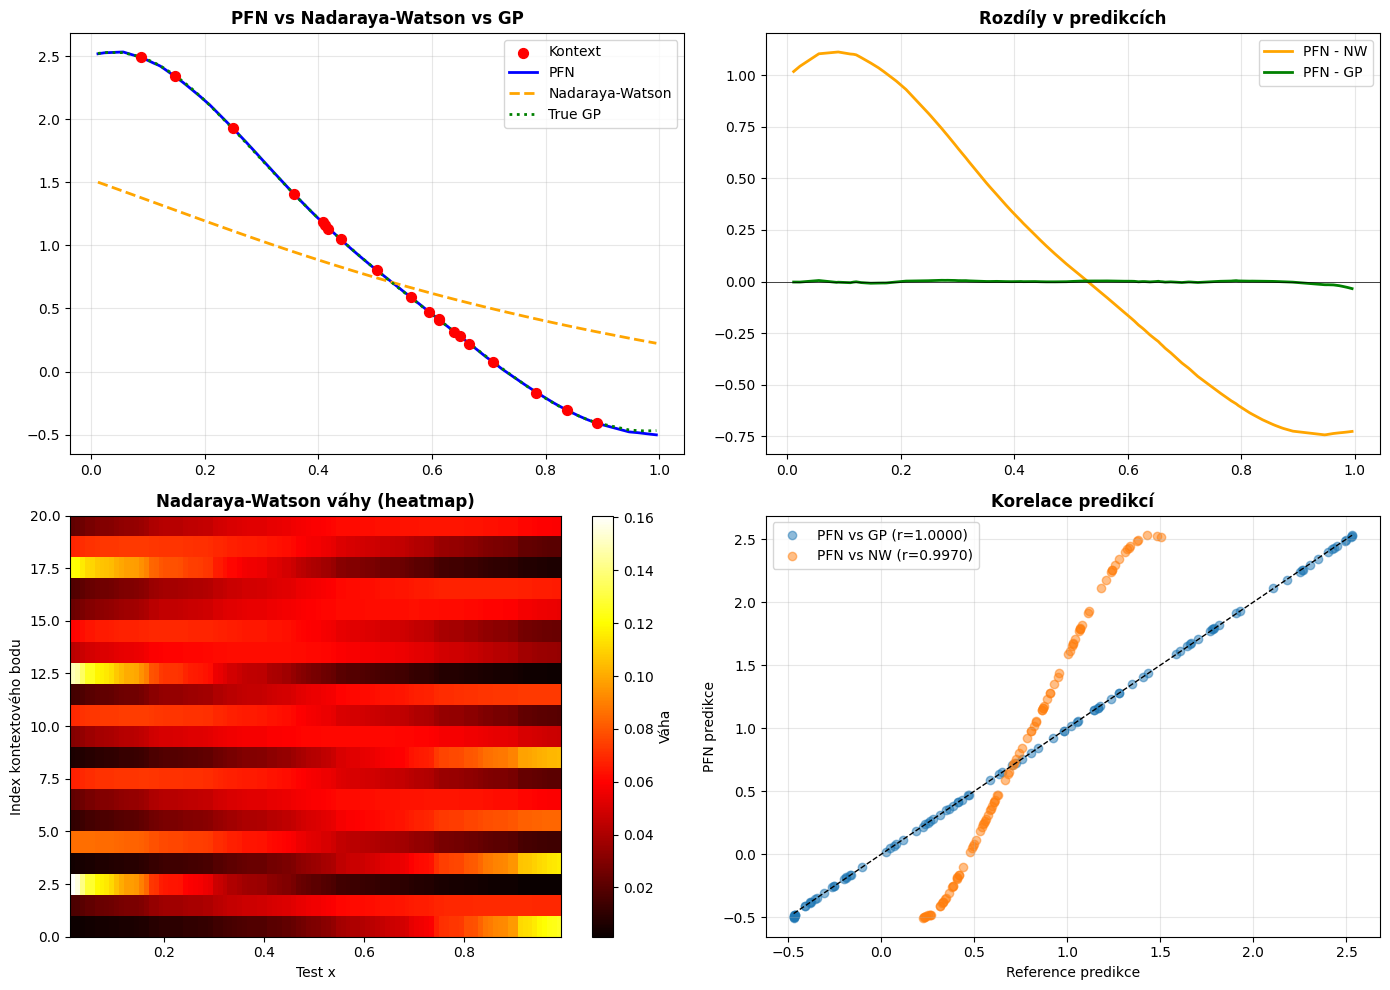

MSE PFN vs GP: 0.000057
MSE PFN vs NW: 0.396248
MSE NW vs GP:  0.393765


In [20]:
# =============================================
# EXPERIMENT 3: Porovnání GP vs PFN vs RBF
# =============================================
# PFN ~ Nadaraya-Watson estimátor: y_pred = sum(w_i * y_i)

def nadaraya_watson_prediction(train_x, train_y, test_x, lengthscale=0.3):
    """
    Nadaraya-Watson kernel estimátor - to co by měl PFN aproximovat.
    """
    train_x_np = train_x.cpu().numpy().reshape(-1)
    train_y_np = train_y.cpu().numpy().reshape(-1)
    test_x_np = test_x.cpu().numpy().reshape(-1)

    predictions = []
    all_weights = []

    for x_test in test_x_np:
        # RBF váhy
        weights = np.exp(-0.5 * (train_x_np - x_test)**2 / lengthscale**2)
        weights_norm = weights / weights.sum()

        # Vážený průměr
        y_pred = np.sum(weights_norm * train_y_np)
        predictions.append(y_pred)
        all_weights.append(weights_norm)

    return np.array(predictions), np.array(all_weights)

# Použije globální train_x, train_y, test_x z buňky DATASET
train_x_1d = train_x[:, 0]   # pro NW a plotting
test_x_1d  = test_x[:, 0]    # pro NW a plotting

# PFN predikce
with torch.no_grad():
    logits = loaded_model(train_x[None], train_y[None], test_x[None])
pfn_means = loaded_model.criterion.mean(logits)[0].cpu().numpy()

# Nadaraya-Watson predikce
nw_preds, nw_weights = nadaraya_watson_prediction(train_x_1d, train_y, test_x_1d, lengthscale=hps['lengthscale'])

# True GP
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=hps['lengthscale'])
gp = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
gp.fit(train_x_1d.cpu().numpy().reshape(-1, 1), train_y.cpu().numpy())
gp_mean = gp.predict(test_x_1d.cpu().numpy().reshape(-1, 1))

# Seřaď
order = test_x_1d.cpu().argsort()
test_x_sorted = test_x_1d.cpu()[order].numpy()

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Porovnání predikcí
ax = axes[0, 0]
ax.scatter(train_x_1d.cpu(), train_y.cpu(), c='red', s=50, zorder=10, label='Kontext')
ax.plot(test_x_sorted, pfn_means[order], 'b-', lw=2, label='PFN')
ax.plot(test_x_sorted, nw_preds[order], 'orange', lw=2, linestyle='--', label='Nadaraya-Watson')
ax.plot(test_x_sorted, gp_mean[order], 'g:', lw=2, label='True GP')
ax.set_title('PFN vs Nadaraya-Watson vs GP', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Rozdíl PFN vs NW
ax = axes[0, 1]
diff_nw = pfn_means[order] - nw_preds[order]
diff_gp = pfn_means[order] - gp_mean[order]
ax.plot(test_x_sorted, diff_nw, 'orange', lw=2, label='PFN - NW')
ax.plot(test_x_sorted, diff_gp, 'green', lw=2, label='PFN - GP')
ax.axhline(y=0, color='black', linestyle='-', lw=0.5)
ax.set_title('Rozdíly v predikcích', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Heatmapa NW vah
ax = axes[1, 0]
im = ax.imshow(nw_weights[order].T, aspect='auto', cmap='hot',
               extent=[test_x_sorted.min(), test_x_sorted.max(), 0, n_context])
ax.set_xlabel('Test x')
ax.set_ylabel('Index kontextového bodu')
ax.set_title('Nadaraya-Watson váhy (heatmap)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Váha')

# 4. Korelace
ax = axes[1, 1]
ax.scatter(gp_mean, pfn_means, alpha=0.5, label=f'PFN vs GP (r={np.corrcoef(gp_mean, pfn_means)[0,1]:.4f})')
ax.scatter(nw_preds, pfn_means, alpha=0.5, label=f'PFN vs NW (r={np.corrcoef(nw_preds, pfn_means)[0,1]:.4f})')
ax.plot([gp_mean.min(), gp_mean.max()], [gp_mean.min(), gp_mean.max()], 'k--', lw=1)
ax.set_xlabel('Reference predikce')
ax.set_ylabel('PFN predikce')
ax.set_title('Korelace predikcí', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MSE PFN vs GP: {np.mean((pfn_means - gp_mean)**2):.6f}")
print(f"MSE PFN vs NW: {np.mean((pfn_means - nw_preds)**2):.6f}")
print(f"MSE NW vs GP:  {np.mean((nw_preds - gp_mean)**2):.6f}")



*   Tady jsou další ukázky porovnání N-W predikcí s PFN a jak moc dobře odpovídají skutečným predikcím GP




n_context= 5: MSE PFN=0.0359±0.0290  MSE GP=0.0543±0.0539
n_context=10: MSE PFN=0.0055±0.0123  MSE GP=0.0038±0.0092
n_context=15: MSE PFN=0.0002±0.0001  MSE GP=0.0003±0.0001
n_context=20: MSE PFN=0.0002±0.0001  MSE GP=0.0003±0.0003


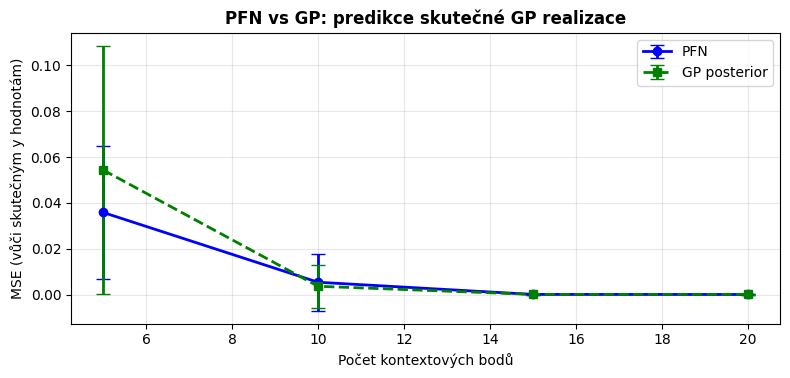

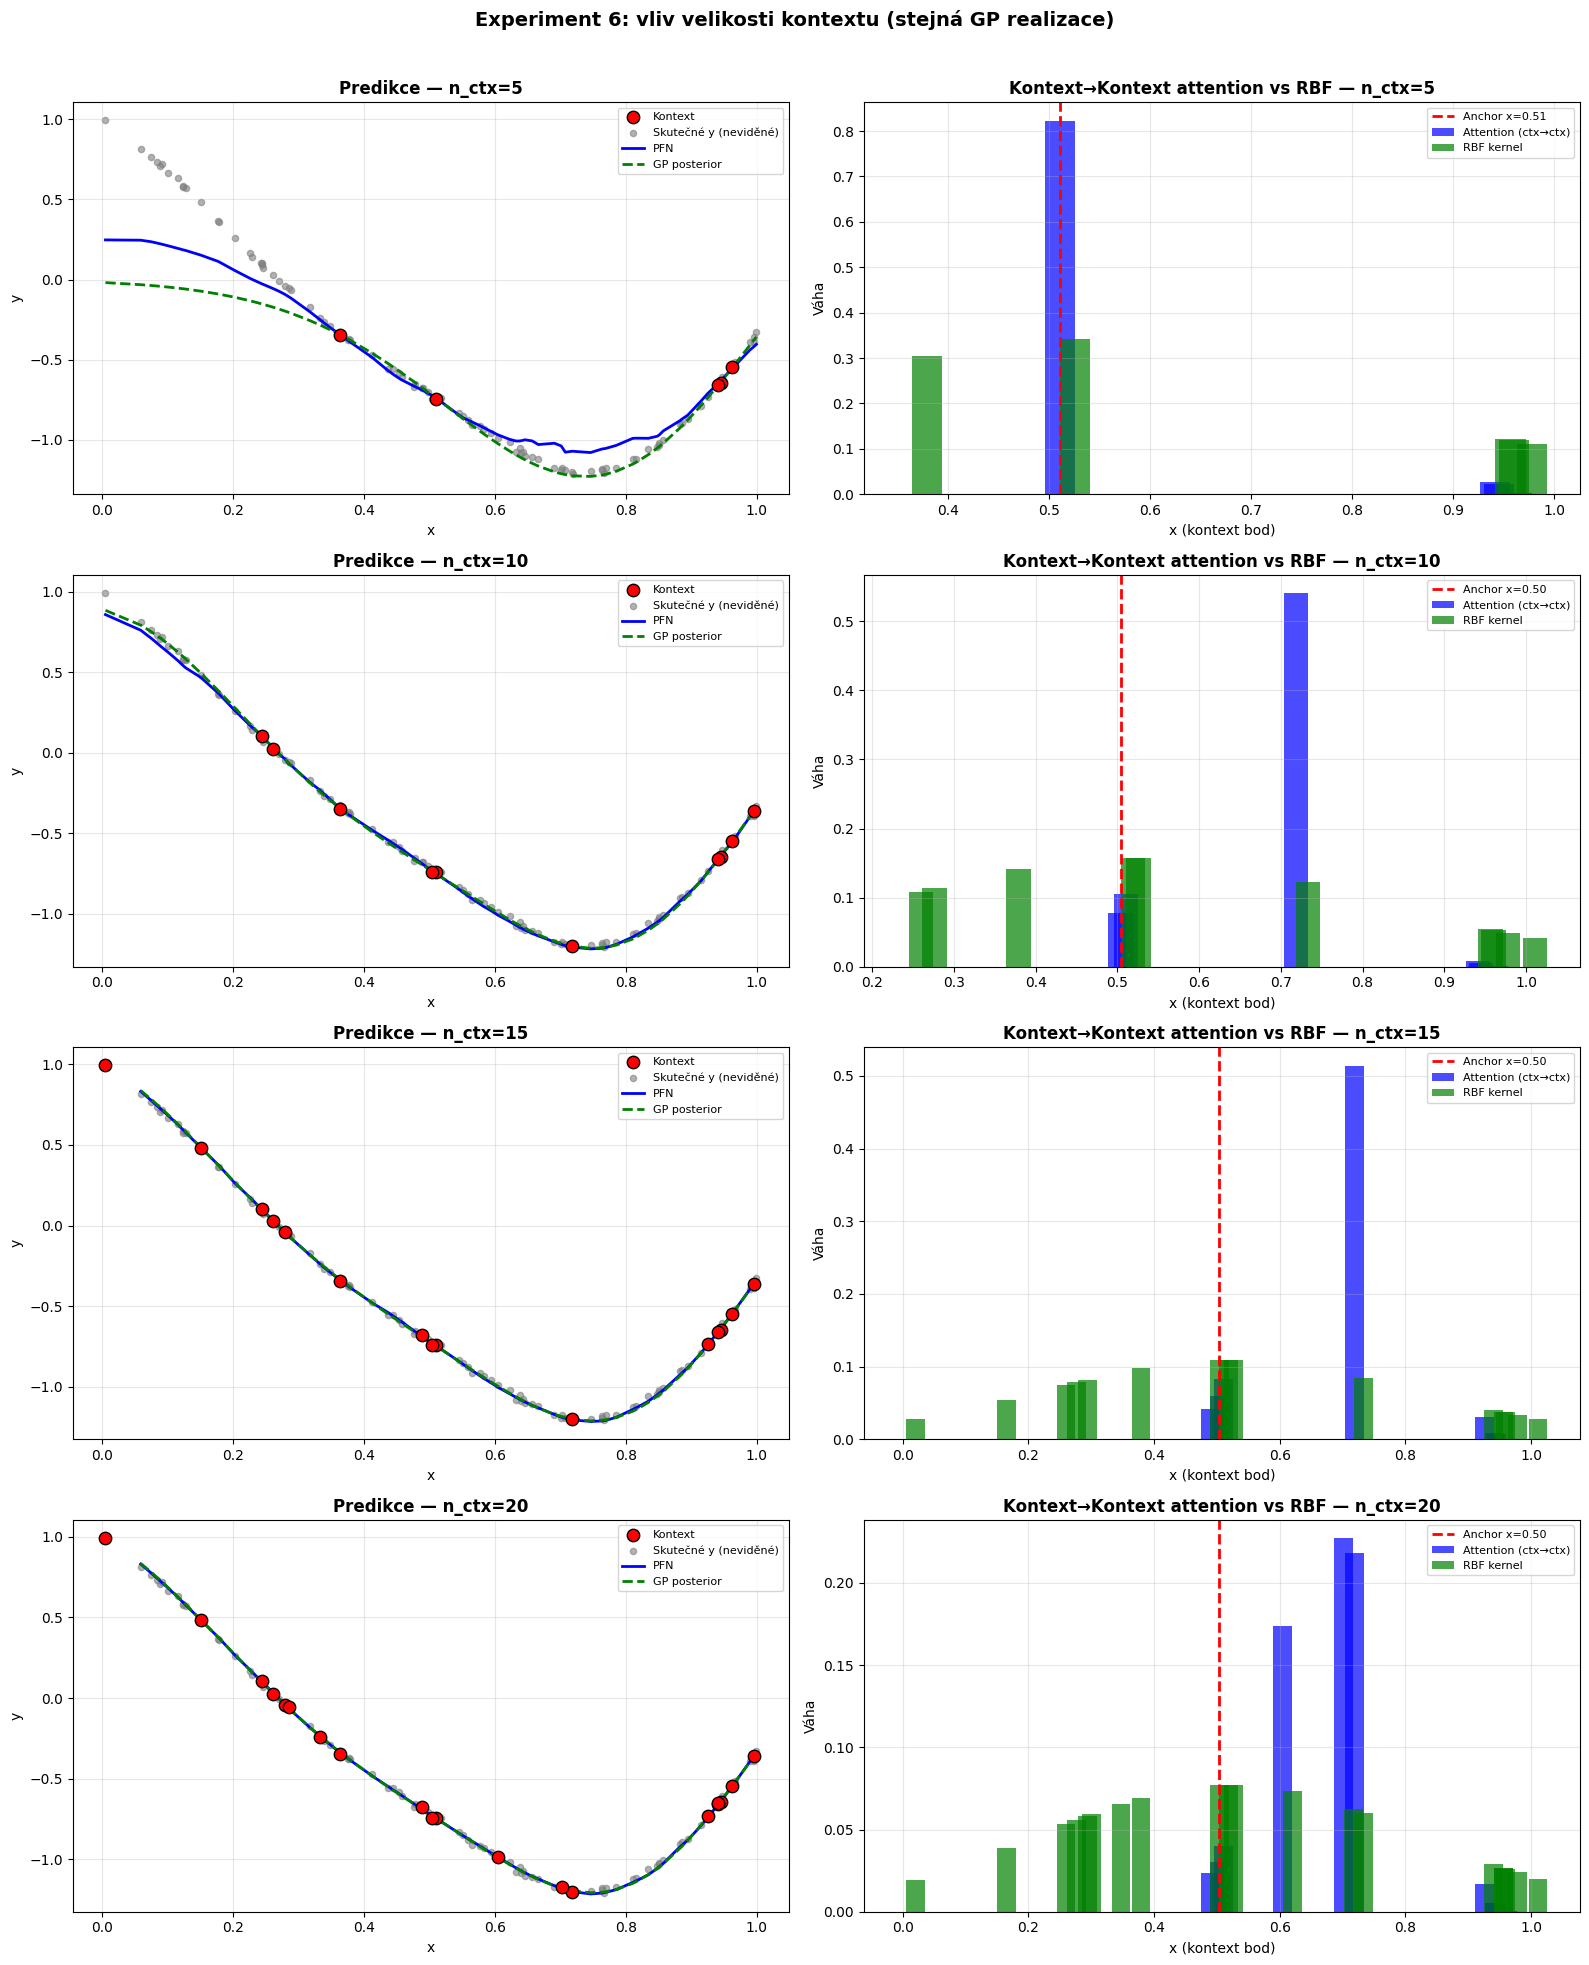

In [21]:
# =============================================
# EXPERIMENT 4: PFN inference na reálné GP realizaci
# =============================================
# PFN dostane pouze část skutečně naměřených bodů
# a musí odhadnout zbývající skutečné hodnoty.
# Ground truth = skutečné nasamplované y hodnoty (ne GP posteriorní mean).

N_CONTEXT_LIST = [5, 10, 15, 20]
N_TOTAL        = 100
TEST_IDX_ATTN  = 25   # index test bodu pro histogram attention vs RBF

def experiment_partial_observation(model, hps, n_total=N_TOTAL, n_context_list=N_CONTEXT_LIST):
    results = []
    for n_ctx in n_context_list:
        mses_pfn, mses_gp = [], []
        for _ in range(20):
            batch  = get_batch_for_gp(batch_size=1, seq_len=n_total, num_features=1, hyperparameters=hps)
            all_x  = batch.x[0]; all_y = batch.y[0]
            idx    = torch.randperm(n_total)
            train_x = all_x[idx[:n_ctx]];  train_y = all_y[idx[:n_ctx]]
            test_x  = all_x[idx[n_ctx:]];  true_y  = all_y[idx[n_ctx:]]

            with torch.no_grad():
                logits = model(train_x[None], train_y[None], test_x[None])
            pfn_pred = model.criterion.mean(logits)[0].cpu().numpy()

            kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=hps['lengthscale'])
            gp     = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
            gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
            gp_pred = gp.predict(test_x.cpu().numpy())

            true_y_np = true_y.cpu().numpy()
            mses_pfn.append(np.mean((pfn_pred - true_y_np)**2))
            mses_gp.append (np.mean((gp_pred  - true_y_np)**2))

        results.append({
            'n_context':    n_ctx,
            'mse_pfn_mean': np.mean(mses_pfn), 'mse_pfn_std': np.std(mses_pfn),
            'mse_gp_mean':  np.mean(mses_gp),  'mse_gp_std':  np.std(mses_gp),
        })
        print(f"n_context={n_ctx:2d}: MSE PFN={np.mean(mses_pfn):.4f}±{np.std(mses_pfn):.4f}  "
              f"MSE GP={np.mean(mses_gp):.4f}±{np.std(mses_gp):.4f}")
    return results


results_partial = experiment_partial_observation(loaded_model, hps)

# --- MSE summary ---
fig0, ax0 = plt.subplots(figsize=(8, 4))
n_ctx_vals = [r['n_context']    for r in results_partial]
ax0.errorbar(n_ctx_vals, [r['mse_pfn_mean'] for r in results_partial],
             yerr=[r['mse_pfn_std'] for r in results_partial],
             marker='o', capsize=5, lw=2, label='PFN', color='blue')
ax0.errorbar(n_ctx_vals, [r['mse_gp_mean']  for r in results_partial],
             yerr=[r['mse_gp_std']  for r in results_partial],
             marker='s', capsize=5, lw=2, label='GP posterior', color='green', linestyle='--')
ax0.set_xlabel('Počet kontextových bodů')
ax0.set_ylabel('MSE (vůči skutečným y hodnotám)')
ax0.set_title('PFN vs GP: predikce skutečné GP realizace', fontweight='bold')
ax0.legend(); ax0.grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()

# --- Jeden řádek grafů pro každý n_ctx ---
# Sdílená realizace GP pro všechny kontexty (stejná data, různě velký kontext)
batch_vis = get_batch_for_gp(batch_size=1, seq_len=N_TOTAL, num_features=1, hyperparameters=hps)
all_x_vis = batch_vis.x[0]; all_y_vis = batch_vis.y[0]
perm      = torch.randperm(N_TOTAL)   # stejná permutace pro všechny n_ctx

fig, axes = plt.subplots(len(N_CONTEXT_LIST), 2, figsize=(16, 5 * len(N_CONTEXT_LIST)))

for row, n_ctx in enumerate(N_CONTEXT_LIST):
    ctx_idx  = perm[:n_ctx];  test_idx_vis = perm[n_ctx:]
    train_x  = all_x_vis[ctx_idx];   train_y  = all_y_vis[ctx_idx]
    test_x   = all_x_vis[test_idx_vis]; true_y = all_y_vis[test_idx_vis]

    # PFN predikce
    with torch.no_grad():
        logits = loaded_model(train_x[None], train_y[None], test_x[None])
    pfn_pred = loaded_model.criterion.mean(logits)[0].cpu().numpy()

    # GP predikce
    kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=hps['lengthscale'])
    gp     = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
    gp.fit(train_x.cpu().numpy(), train_y.cpu().numpy())
    gp_pred = gp.predict(test_x.cpu().numpy())

    t_order = test_x[:, 0].cpu().argsort()

    # ── levý sloupec: predikce ──
    ax_pred = axes[row, 0]
    ax_pred.scatter(train_x[:, 0].cpu(), train_y.cpu(),
                    c='red', s=80, zorder=10, label='Kontext', edgecolors='black')
    ax_pred.scatter(test_x[t_order, 0].cpu(), true_y.cpu()[t_order],
                    c='gray', s=20, alpha=0.6, label='Skutečné y (neviděné)')
    ax_pred.plot(test_x[t_order, 0].cpu(), pfn_pred[t_order], 'b-',  lw=2, label='PFN')
    ax_pred.plot(test_x[t_order, 0].cpu(), gp_pred[t_order],  'g--', lw=2, label='GP posterior')
    ax_pred.set_title(f'Predikce — n_ctx={n_ctx}', fontweight='bold')
    ax_pred.set_xlabel('x'); ax_pred.set_ylabel('y')
    ax_pred.legend(fontsize=8); ax_pred.grid(True, alpha=0.3)

    # ── pravý sloupec: attention kontext→kontext vs RBF ──
    # Vybereme kontext bod uprostřed x rozsahu — ten "vidí" ostatní kontext body
    all_seq_x = torch.cat([train_x, test_x], dim=0)
    attn_w, _ = compute_attention_weights(loaded_model, train_x, train_y, all_seq_x)
    attn_layer5 = attn_w[5][0, 0].mean(dim=0).detach().numpy()

    train_x_np  = train_x[:, 0].cpu().numpy()
    order       = np.argsort(train_x_np)
    # Vyber kontext bod nejblíže x=0.5
    ctx_pick    = int(np.argmin(np.abs(train_x_np - 0.5)))
    anchor_x    = train_x_np[ctx_pick]

    # Attention tohoto kontext bodu na VŠECHNY ostatní kontext body
    attn_ctx2ctx = attn_layer5[ctx_pick, :n_ctx]   # řádek ctx_pick, sloupce 0..n_ctx

    # RBF kernel: k(anchor, x_j) normalizovaný — to co by dělal kernel smoothing
    rbf_raw  = np.exp(-0.5 * (train_x_np - anchor_x)**2 / hps['lengthscale']**2)
    rbf_norm = rbf_raw / rbf_raw.sum()

    ax_attn = axes[row, 1]
    ax_attn.bar(train_x_np[order],         attn_ctx2ctx[order], width=0.03,
                alpha=0.7, label='Attention (ctx→ctx)', color='blue')
    ax_attn.bar(train_x_np[order] + 0.015, rbf_norm[order],     width=0.03,
                alpha=0.7, label='RBF kernel', color='green')
    ax_attn.axvline(x=anchor_x, color='red', linestyle='--', lw=2,
                    label=f'Anchor x={anchor_x:.2f}')
    ax_attn.set_title(f'Kontext→Kontext attention vs RBF — n_ctx={n_ctx}', fontweight='bold')
    ax_attn.set_xlabel('x (kontext bod)'); ax_attn.set_ylabel('Váha')
    ax_attn.legend(fontsize=8); ax_attn.grid(True, alpha=0.3)

plt.suptitle('Experiment 6: vliv velikosti kontextu (stejná GP realizace)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Interpretace — Experiment 4

**Kontext→Kontext attention je nelokální.** Anchor bod (x≈0.5) dává silnou attention na vzdálený bod (x≈0.7–0.8), ne na nejbližší sousedy. RBF kernel by naopak koncentroval váhu lokálně. Tento rozdíl je konzistentní napříč různými realizacemi i různými velikostmi kontextu.

**Proč nelokálnost dává smysl.** GP posterior mean vyžaduje výpočet K⁻¹y. Matice K⁻¹ (inverze kernel matice) má obecně nenulové mimobiagonální prvky i tam, kde K je malá — inverze "rozšiřuje" informaci globálně. Attention kontext→kontext pravděpodobně aproximuje právě tuto operaci, proto není lokální jako K samotná.

**Causal masking není přítomen.** Zdrojový kód `MultiHeadAttention.forward` neobsahuje žádnou masku. Zdánlivá asymmetrie (nízká attention na body "vlevo od anchoru") není způsobena maskováním, ale náhodným pořadím tokenů — token index neodpovídá prostorovému pořadí podle x.

## Experiment 6: Jedna attention hlava vs Nadaraya-Watson

Testujeme, zda se jednotlivé attention hlavy chovají jako **Nadaraya-Watson estimátor** s RBF kernelem.

Porovnáváme:
- Attention váhy jedné hlavy vs RBF kernel váhy
- Predikci `attn @ y_train` vs NW predikci vs plný PFN vs true GP
- Systematický scan všech 48 hlav (6 vrstev × 8 hlav)

EXPERIMENT 6: Jedna attention hlava vs Nadaraya-Watson

--- Detailní vizualizace pro vybrané hlavy ---


=== VRSTVA 0, HLAVA 0 ===
Korelace attention vs RBF kernel: 0.4619

MSE (Mean Squared Error):
  Single head vs NW:  0.249902
  Single head vs PFN: 0.495719
  Single head vs GP:  0.495538
  NW vs GP:           0.137010
  Full PFN vs GP:     0.000011


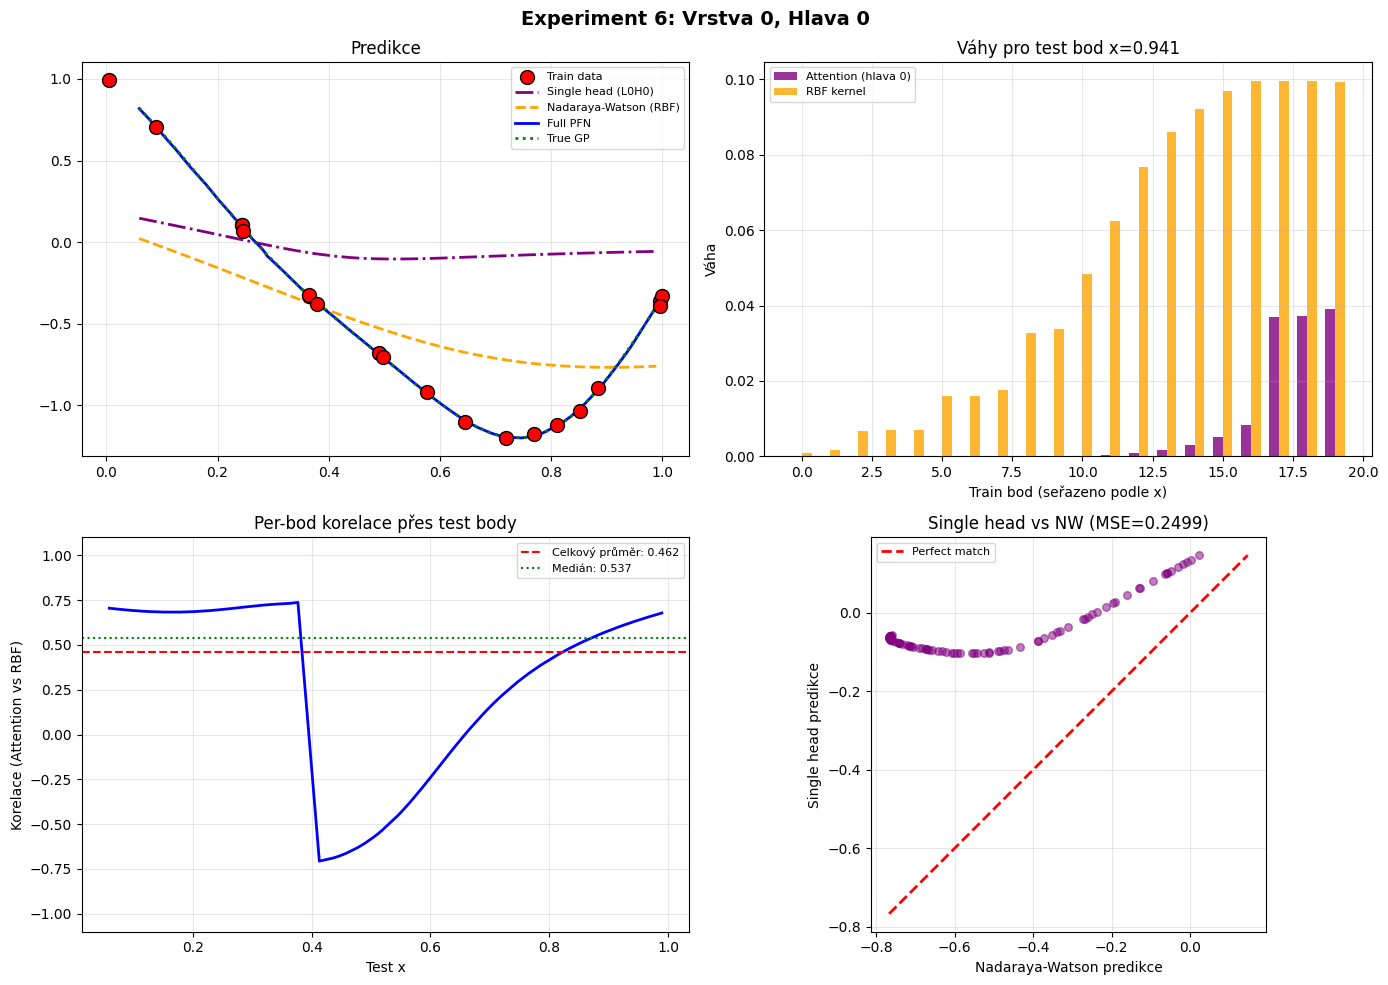


=== VRSTVA 0, HLAVA 3 ===
Korelace attention vs RBF kernel: 0.1818

MSE (Mean Squared Error):
  Single head vs NW:  0.240394
  Single head vs PFN: 0.530499
  Single head vs GP:  0.530561
  NW vs GP:           0.137010
  Full PFN vs GP:     0.000011


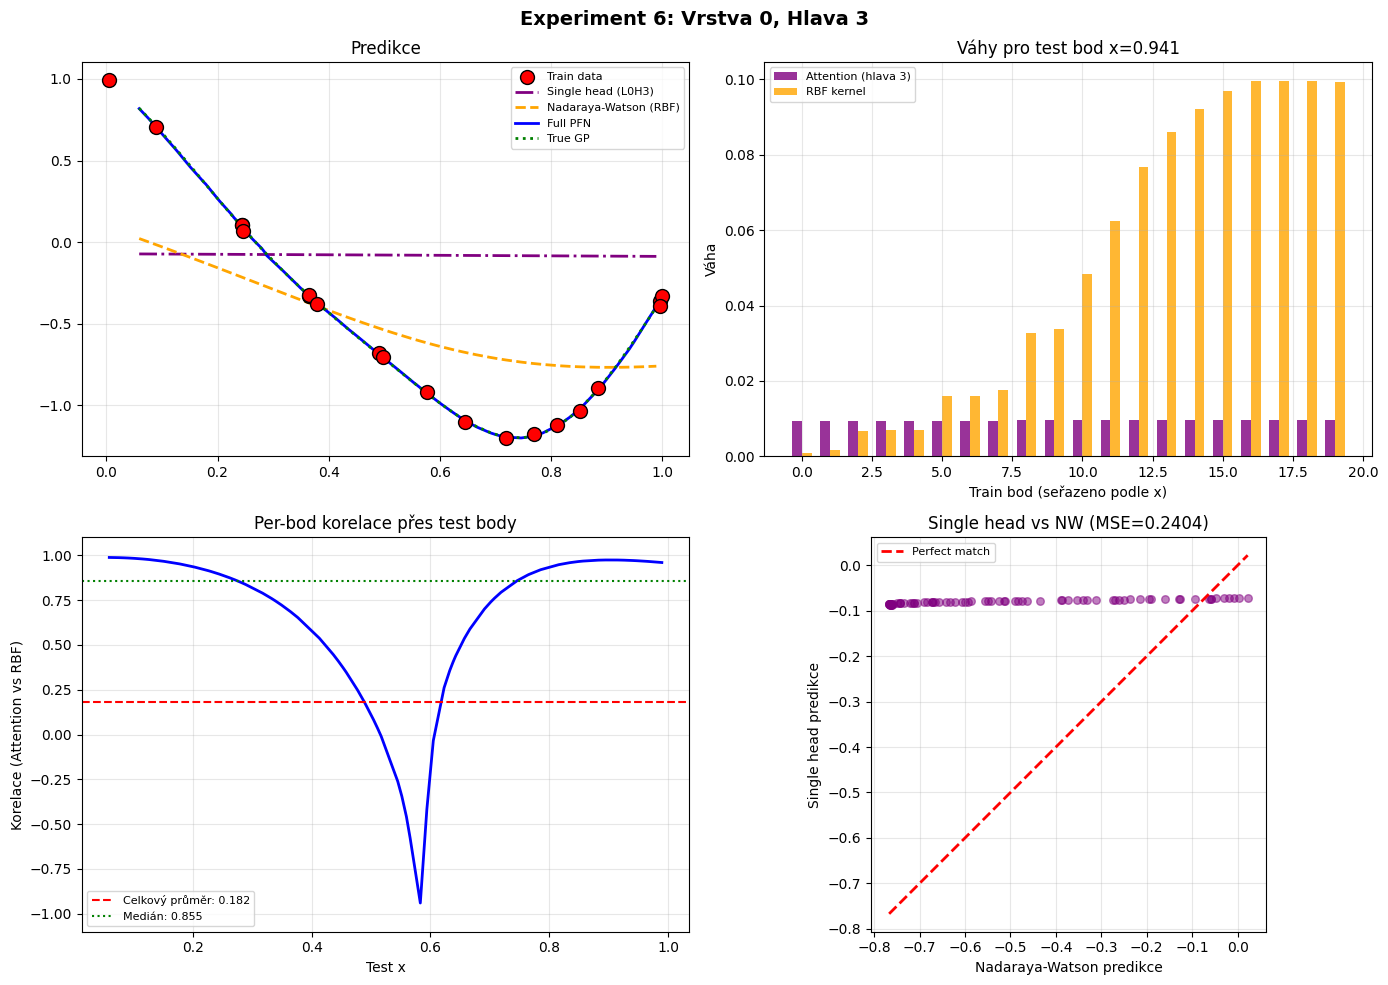


=== VRSTVA 0, HLAVA 7 ===
Korelace attention vs RBF kernel: 0.0549

MSE (Mean Squared Error):
  Single head vs NW:  0.294189
  Single head vs PFN: 0.595683
  Single head vs GP:  0.595712
  NW vs GP:           0.137010
  Full PFN vs GP:     0.000011


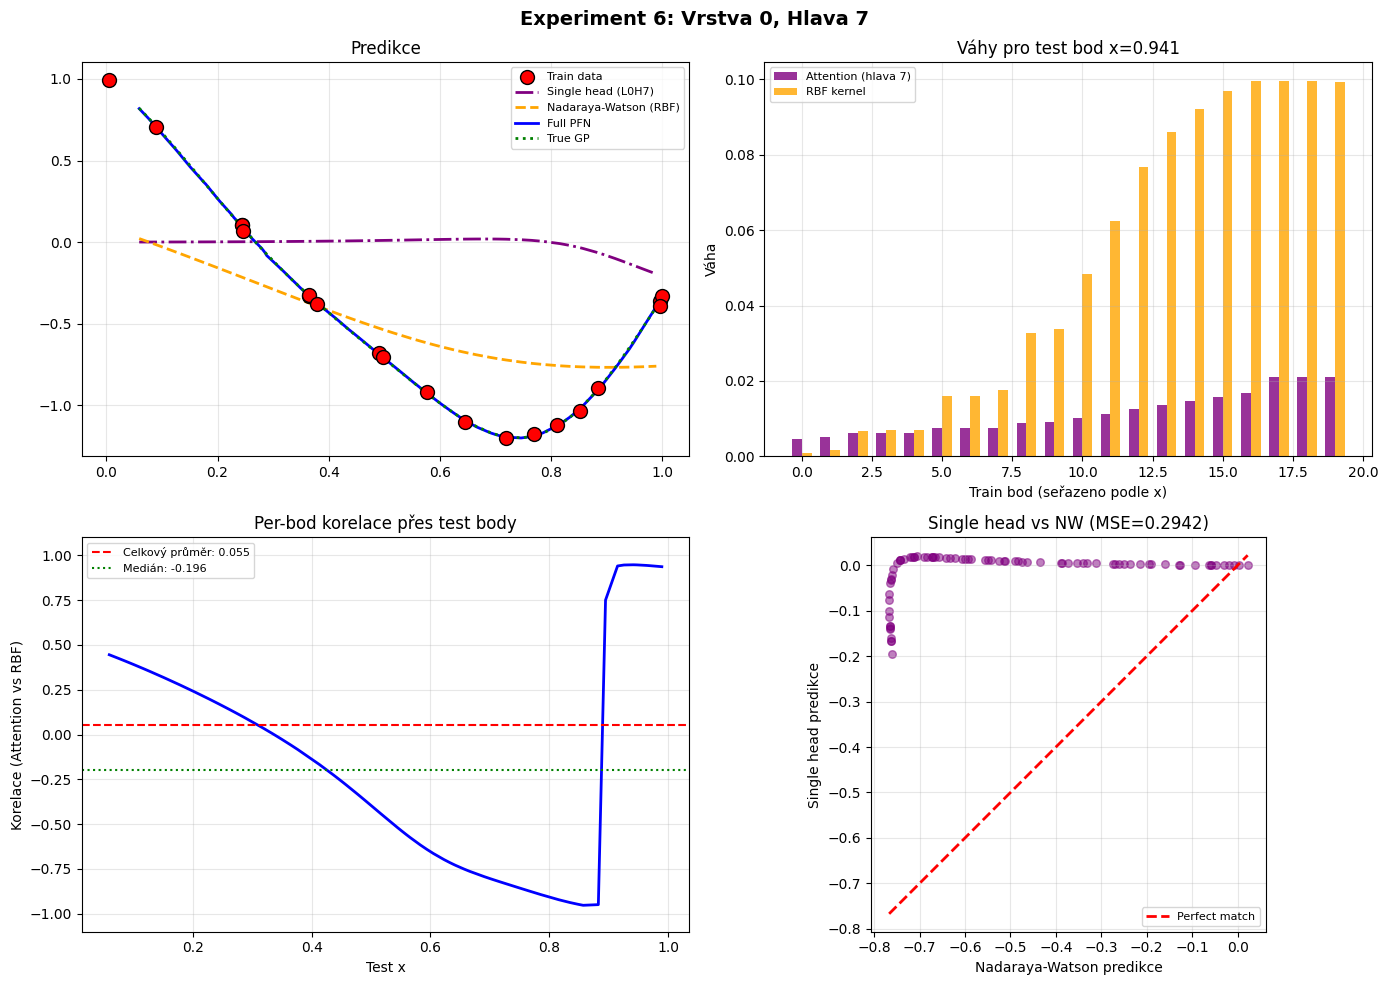


=== VRSTVA 5, HLAVA 0 ===
Korelace attention vs RBF kernel: 0.2742

MSE (Mean Squared Error):
  Single head vs NW:  0.324059
  Single head vs PFN: 0.580681
  Single head vs GP:  0.580441
  NW vs GP:           0.137010
  Full PFN vs GP:     0.000011


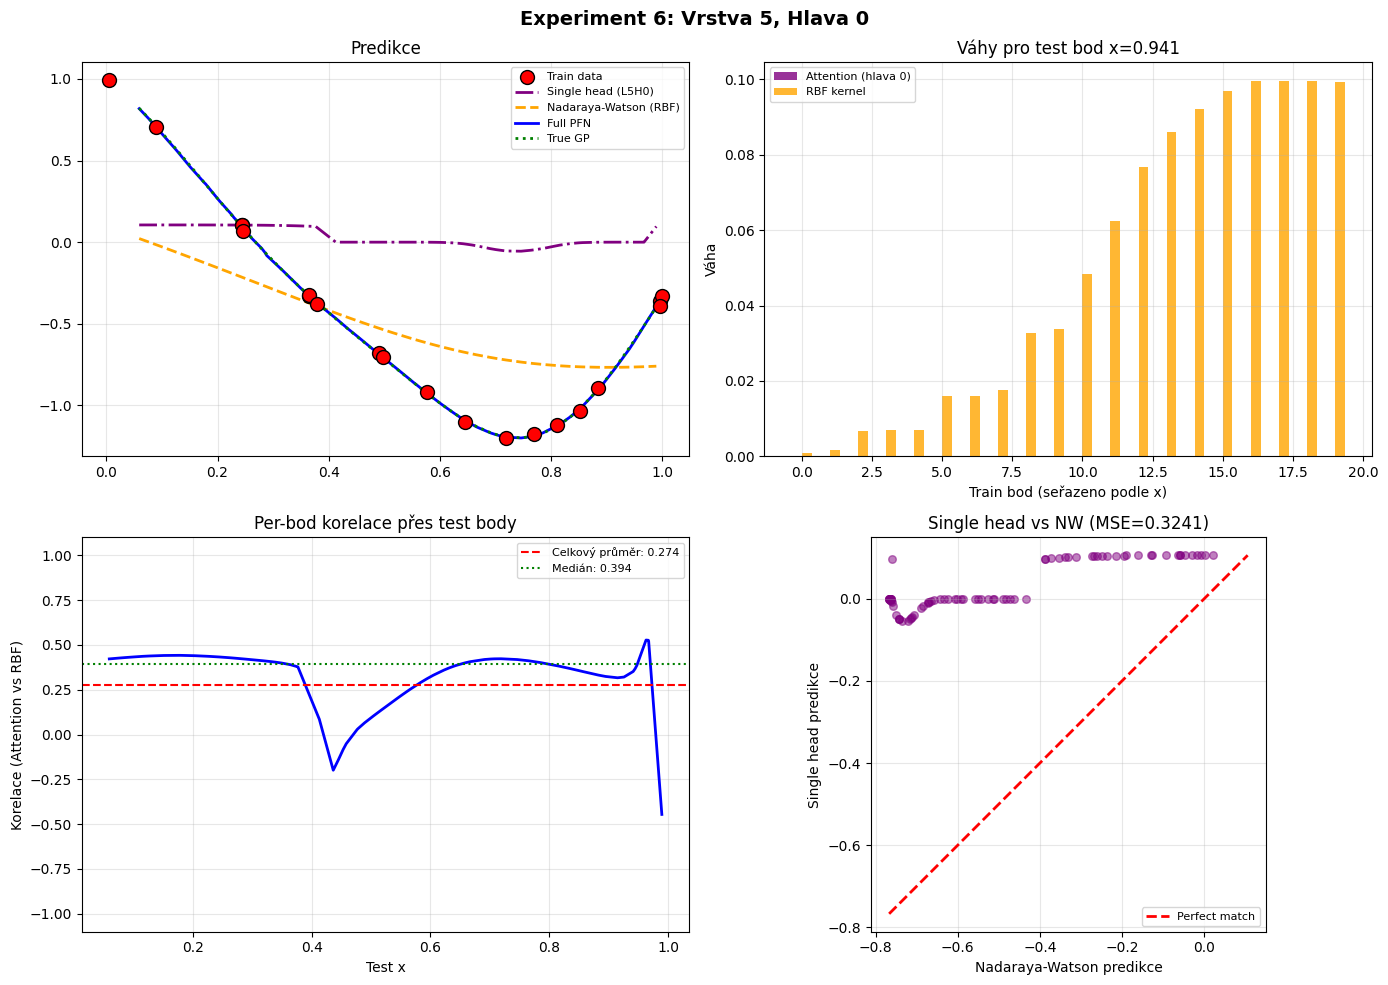


=== VRSTVA 5, HLAVA 3 ===
Korelace attention vs RBF kernel: 0.3559

MSE (Mean Squared Error):
  Single head vs NW:  0.377055
  Single head vs PFN: 0.132521
  Single head vs GP:  0.132592
  NW vs GP:           0.137010
  Full PFN vs GP:     0.000011


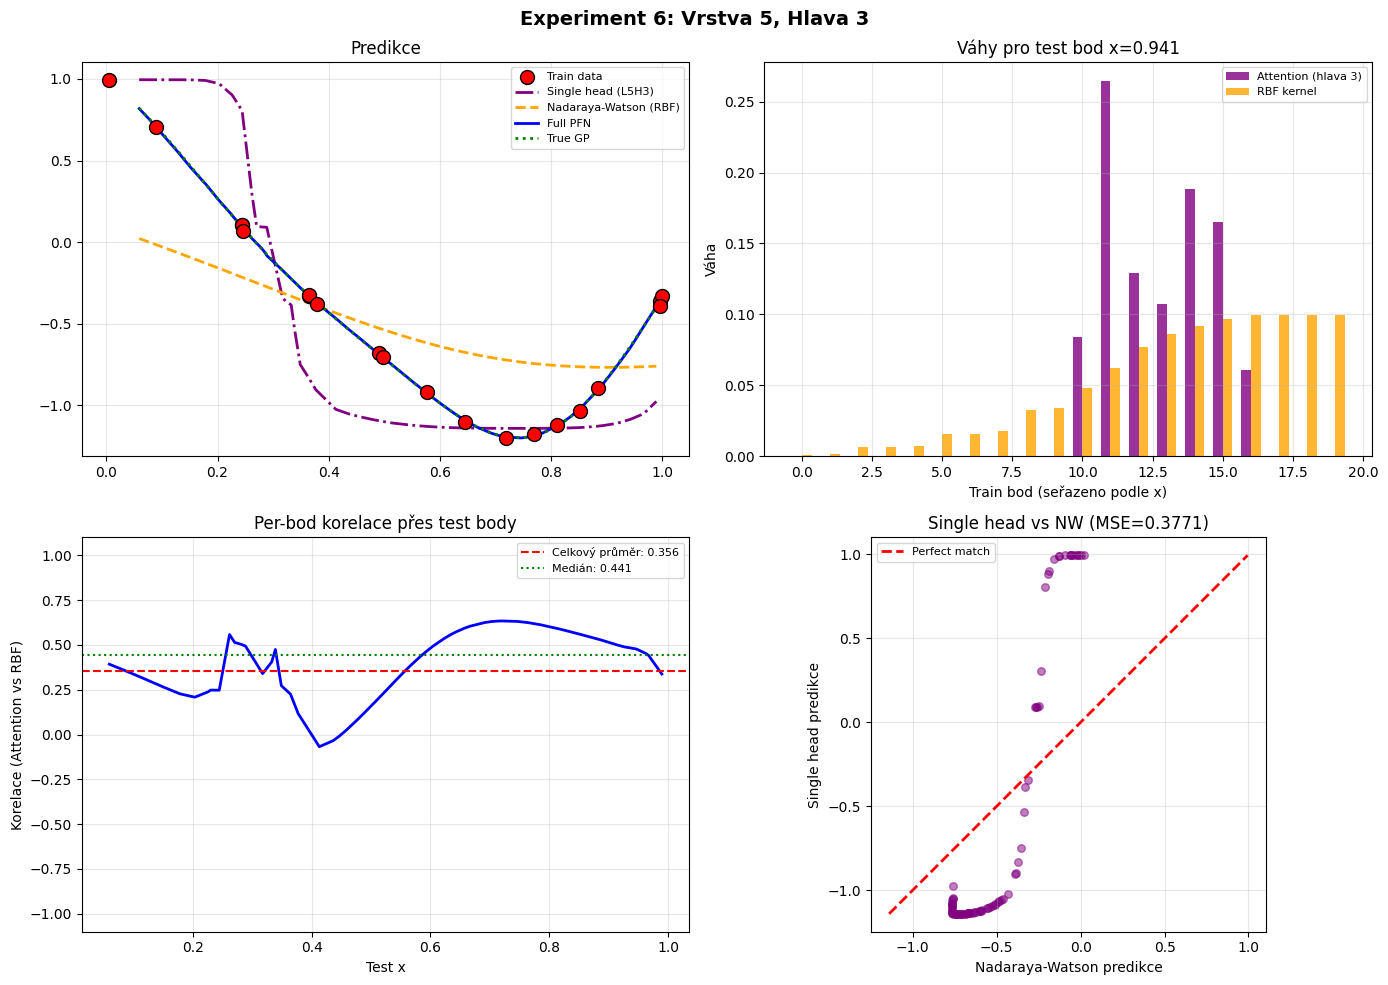


=== VRSTVA 5, HLAVA 7 ===
Korelace attention vs RBF kernel: 0.1251

MSE (Mean Squared Error):
  Single head vs NW:  0.267980
  Single head vs PFN: 0.366014
  Single head vs GP:  0.365007
  NW vs GP:           0.137010
  Full PFN vs GP:     0.000011


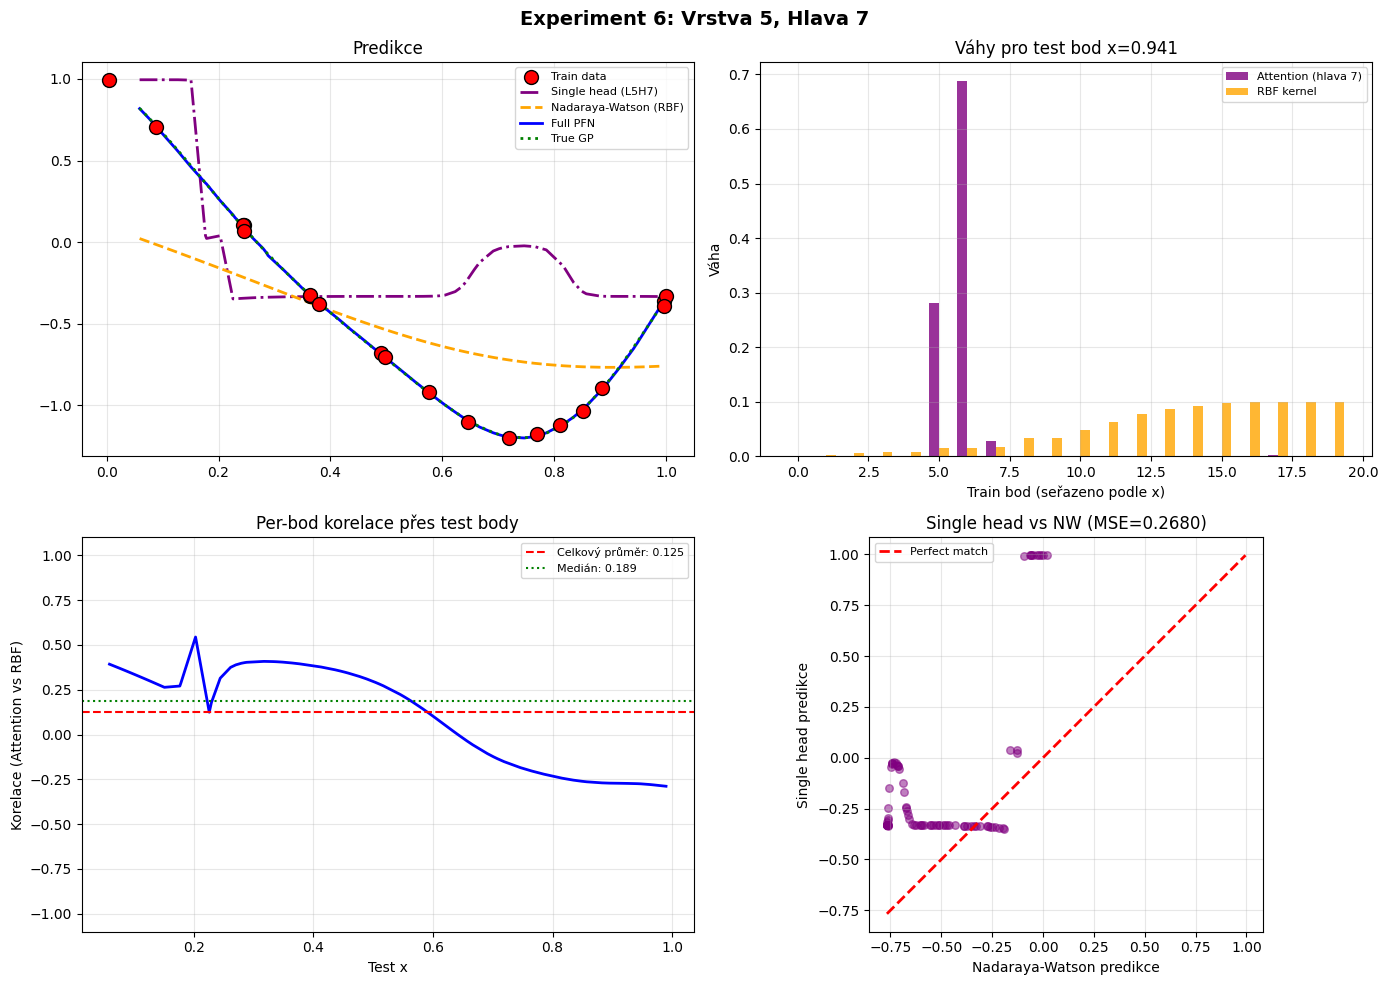


--- Systematický scan všech 48 hlav ---

Trial 1/5...
Trial 2/5...
Trial 3/5...
Trial 4/5...
Trial 5/5...


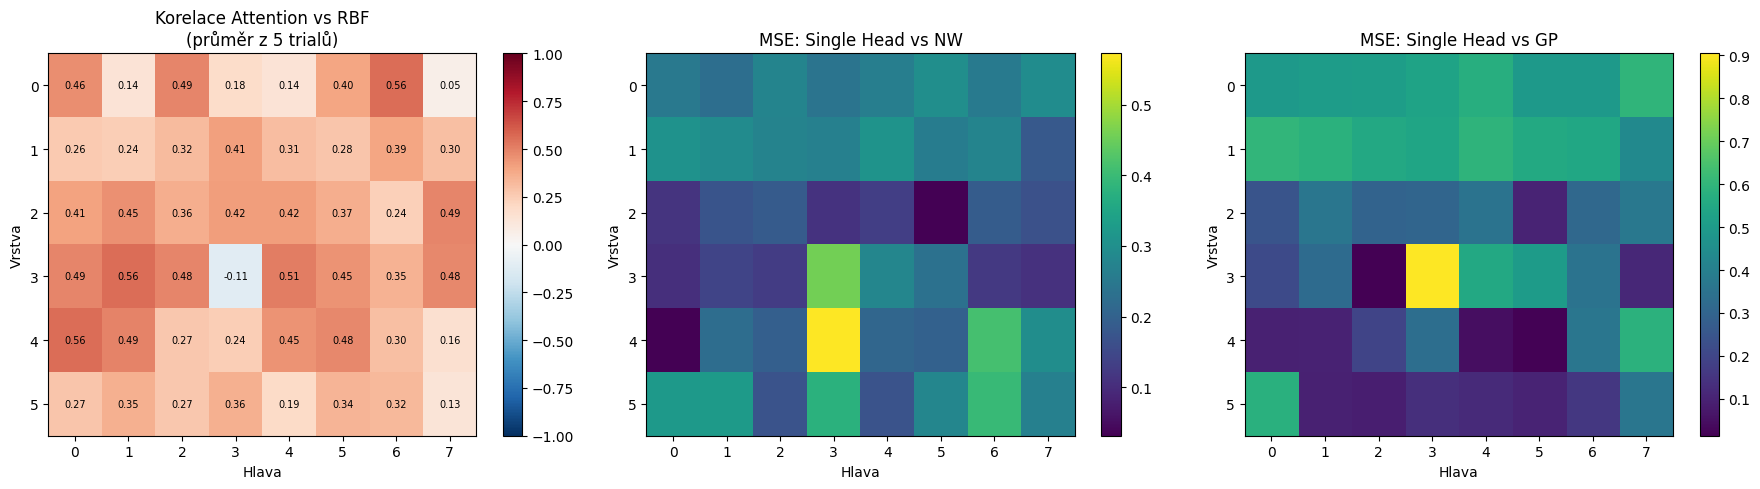


Nejvyšší korelace s RBF: vrstva 3, hlava 1 (corr = 0.5559)

=== KOMPLETNÍ SHRNUTÍ ===
Vrstva   Hlava  Corr(Attn,RBF)     MSE(Head,NW)    MSE(Head,GP)   
--------------------------------------------------------------
0        0      0.4619             0.249902        0.495538       
0        1      0.1374             0.226319        0.506239       
0        2      0.4852             0.275100        0.508773       
0        3      0.1818             0.240394        0.530561       
0        4      0.1374             0.262864        0.572091       
0        5      0.3960             0.298653        0.497286       
0        6      0.5551             0.255315        0.491609       
0        7      0.0549             0.294189        0.595712       
1        0      0.2639             0.307249        0.598909       
1        1      0.2450             0.292473        0.583940       
1        2      0.3161             0.272899        0.551600       
1        3      0.4131             0.267295   

In [22]:
# =============================================
# EXPERIMENT 6: Jedna attention hlava vs Nadaraya-Watson
# =============================================

def extract_single_head_attention(model, train_x, train_y, test_x, layer_idx=0, head_idx=0):
    """
    Extrahuje attention váhy z jedné konkrétní hlavy v jedné vrstvě.

    DŮLEŽITÉ: train_x, train_y, test_x mají být BEZ batch dimenze.
    Funkce compute_attention_weights si [None] přidá sama.
    """
    attn_weights_all, _ = compute_attention_weights(
        model, train_x, train_y, test_x
    )

    # attn_weights_all[layer_idx] má tvar [1, 1, n_heads, seq_len, seq_len]
    # Vybereme konkrétní hlavu: [seq_len, seq_len]
    head_attn = attn_weights_all[layer_idx][0, 0, head_idx].detach().numpy()

    return head_attn


def test_single_head_hypothesis(model, hps, layer_idx=0, head_idx=0, n_context=20, seq_len=100):
    """
    Testuje, zda se jedna attention hlava chová jako Nadaraya-Watson estimátor.

    Porovnává:
    - Attention váhy jedné hlavy vs RBF kernel váhy
    - Predikci "attn @ y_train" vs NW predikci vs plný PFN vs true GP
    """

    # === GENERACE DAT ===
    batch = get_batch_for_gp(
        batch_size=1, seq_len=seq_len, num_features=1,
        hyperparameters=hps
    )

    train_x = batch.x[0, :n_context]     # [n_context, 1]
    train_y = batch.y[0, :n_context]      # [n_context]
    test_x = batch.x[0]                   # [seq_len, 1] — celá sekvence

    n_test = seq_len - n_context  # = 80

    # === 1. ATTENTION VÁHY JEDNÉ HLAVY ===
    head_attn = extract_single_head_attention(
        model, train_x, train_y, test_x,
        layer_idx=layer_idx, head_idx=head_idx
    )
    # head_attn má tvar [seq_len, seq_len]

    # Kvadrant Test→Train: jak moc se test body dívají na train body
    n_train = n_context
    test_to_train_attn = head_attn[n_train + n_context:, :n_train]

    # "Predikce" jedné hlavy: váhovaný průměr train_y pomocí attention vah
    # (to je přesně NW estimátor, pokud kernel = attention kernel)
    train_y_np = train_y.cpu().numpy()
    single_head_pred = test_to_train_attn @ train_y_np  # [n_test]

    # === 2. RBF KERNEL VÁHY ===
    train_x_np = train_x.cpu().numpy().reshape(-1)          # [n_context]
    test_x_only = test_x[n_context:]                         # [n_test, 1]
    test_x_only_np = test_x_only.cpu().numpy().reshape(-1)   # [n_test]

    ls = hps['lengthscale']
    # Vektorizovaný výpočet: [n_test, n_context]
    dists_sq = (test_x_only_np[:, None] - train_x_np[None, :]) ** 2
    rbf_raw = np.exp(-0.5 * dists_sq / ls**2)
    rbf_weights = rbf_raw / rbf_raw.sum(axis=1, keepdims=True)  # normalizace

    # === 3. NADARAYA-WATSON PREDIKCE (s RBF kernelem) ===
    nw_pred = rbf_weights @ train_y_np  # [n_test]

    # === 4. PLNÝ PFN PREDIKCE ===
    with torch.no_grad():
        logits = model(train_x[None], train_y[None], test_x[None])
    pfn_pred_all = model.criterion.mean(logits)[0].cpu().numpy()  # [seq_len]
    pfn_pred = pfn_pred_all[n_context:]  # [n_test] — jen pro test body

    # === 5. TRUE GP PREDIKCE ===
    kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=ls)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
    gp.fit(train_x.cpu().numpy(), train_y_np)
    gp_pred = gp.predict(test_x_only.cpu().numpy())  # [n_test]

    # === ANALÝZA ===
    # Korelace: attention váhy vs RBF kernel váhy (celkově)
    corr_attn_rbf = np.corrcoef(
        test_to_train_attn.flatten(),
        rbf_weights.flatten()
    )[0, 1]

    # MSE predikcí — vše má teď konzistentně tvar [n_test]
    mse_head_vs_nw  = np.mean((single_head_pred - nw_pred) ** 2)
    mse_head_vs_pfn = np.mean((single_head_pred - pfn_pred) ** 2)
    mse_head_vs_gp  = np.mean((single_head_pred - gp_pred) ** 2)
    mse_nw_vs_gp    = np.mean((nw_pred - gp_pred) ** 2)
    mse_pfn_vs_gp   = np.mean((pfn_pred - gp_pred) ** 2)

    print(f"\n=== VRSTVA {layer_idx}, HLAVA {head_idx} ===")
    print(f"Korelace attention vs RBF kernel: {corr_attn_rbf:.4f}")
    print(f"\nMSE (Mean Squared Error):")
    print(f"  Single head vs NW:  {mse_head_vs_nw:.6f}")
    print(f"  Single head vs PFN: {mse_head_vs_pfn:.6f}")
    print(f"  Single head vs GP:  {mse_head_vs_gp:.6f}")
    print(f"  NW vs GP:           {mse_nw_vs_gp:.6f}")
    print(f"  Full PFN vs GP:     {mse_pfn_vs_gp:.6f}")

    # === VIZUALIZACE ===
    test_order = test_x_only_np.argsort()
    test_x_sorted = test_x_only_np[test_order]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f'Experiment 6: Vrstva {layer_idx}, Hlava {head_idx}',
        fontsize=14, fontweight='bold'
    )

    # ------ Panel 1: Porovnání predikcí ------
    ax = axes[0, 0]
    ax.scatter(train_x_np, train_y_np, c='red', s=100, zorder=10,
               label='Train data', edgecolors='black')
    ax.plot(test_x_sorted, single_head_pred[test_order], 'purple', lw=2,
            label=f'Single head (L{layer_idx}H{head_idx})', linestyle='-.')
    ax.plot(test_x_sorted, nw_pred[test_order], 'orange', lw=2,
            label='Nadaraya-Watson (RBF)', linestyle='--')
    ax.plot(test_x_sorted, pfn_pred[test_order], 'blue', lw=2,
            label='Full PFN')
    ax.plot(test_x_sorted, gp_pred[test_order], 'green', lw=2,
            label='True GP', linestyle=':')
    ax.set_title('Predikce')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ------ Panel 2: Attention váhy vs RBF pro JEDEN test bod ------
    mid_test_idx = n_test // 2
    actual_x_value = test_x_only_np[mid_test_idx]

    # Seřadíme train body podle x pro lepší vizualizaci
    train_order = train_x_np.argsort()
    train_x_sorted = train_x_np[train_order]

    ax = axes[0, 1]
    width = 0.35
    indices = np.arange(n_context)
    ax.bar(indices - width/2, test_to_train_attn[mid_test_idx][train_order],
           width, alpha=0.8, label=f'Attention (hlava {head_idx})', color='purple')
    ax.bar(indices + width/2, rbf_weights[mid_test_idx][train_order],
           width, alpha=0.8, label='RBF kernel', color='orange')
    ax.set_xlabel('Train bod (seřazeno podle x)')
    ax.set_ylabel('Váha')
    ax.set_title(f'Váhy pro test bod x={actual_x_value:.3f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ------ Panel 3: Per-test-bod korelace attention vs RBF ------
    ax = axes[1, 0]
    correlations = []
    for i in range(n_test):
        c = np.corrcoef(test_to_train_attn[i], rbf_weights[i])[0, 1]
        correlations.append(c if not np.isnan(c) else 0.0)
    correlations = np.array(correlations)

    ax.plot(test_x_sorted, correlations[test_order], 'b-', lw=2)
    ax.axhline(y=corr_attn_rbf, color='red', linestyle='--',
               label=f'Celkový průměr: {corr_attn_rbf:.3f}')
    ax.axhline(y=np.median(correlations), color='green', linestyle=':',
               label=f'Medián: {np.median(correlations):.3f}')
    ax.set_xlabel('Test x')
    ax.set_ylabel('Korelace (Attention vs RBF)')
    ax.set_title('Per-bod korelace přes test body')
    ax.set_ylim(-1.1, 1.1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ------ Panel 4: Scatter — single head pred vs NW pred ------
    ax = axes[1, 1]
    ax.scatter(nw_pred, single_head_pred, alpha=0.5, s=30, c='purple')
    lims = [min(nw_pred.min(), single_head_pred.min()),
            max(nw_pred.max(), single_head_pred.max())]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect match')
    ax.set_xlabel('Nadaraya-Watson predikce')
    ax.set_ylabel('Single head predikce')
    ax.set_title(f'Single head vs NW (MSE={mse_head_vs_nw:.4f})')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

    return {
        'layer': layer_idx,
        'head': head_idx,
        'corr_attn_rbf': corr_attn_rbf,
        'mse_head_vs_nw': mse_head_vs_nw,
        'mse_head_vs_pfn': mse_head_vs_pfn,
        'mse_head_vs_gp': mse_head_vs_gp,
        'mse_nw_vs_gp': mse_nw_vs_gp,
        'mse_pfn_vs_gp': mse_pfn_vs_gp,
    }


def scan_all_heads(model, hps, n_layers=6, n_heads=8, n_trials=5):
    """
    Systematicky prohledá všechny hlavy ve všech vrstvách.
    Průměruje přes více realizací dat pro robustní výsledky.

    Cíl: najít, které hlavy mají nejvyšší korelaci s RBF kernelem
    (= chovají se nejvíc jako Nadaraya-Watson).
    """
    # Matice výsledků: [n_layers, n_heads]
    corr_matrix = np.zeros((n_layers, n_heads))
    mse_head_nw_matrix = np.zeros((n_layers, n_heads))
    mse_head_gp_matrix = np.zeros((n_layers, n_heads))

    for trial in range(n_trials):
        print(f"Trial {trial+1}/{n_trials}...")

        batch = get_batch_for_gp(
            batch_size=1, seq_len=100, num_features=1,
            hyperparameters=hps
        )
        n_context = 20
        train_x = batch.x[0, :n_context]
        train_y = batch.y[0, :n_context]
        test_x = batch.x[0]
        n_test = 100 - n_context

        train_y_np = train_y.cpu().numpy()
        train_x_np = train_x.cpu().numpy().reshape(-1)
        test_x_only_np = test_x[n_context:].cpu().numpy().reshape(-1)

        # RBF váhy (společné pro všechny hlavy)
        ls = hps['lengthscale']
        dists_sq = (test_x_only_np[:, None] - train_x_np[None, :]) ** 2
        rbf_raw = np.exp(-0.5 * dists_sq / ls**2)
        rbf_weights = rbf_raw / rbf_raw.sum(axis=1, keepdims=True)
        nw_pred = rbf_weights @ train_y_np

        # GP predikce
        kernel = ConstantKernel(hps['outputscale']) * RBF(length_scale=ls)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=hps['noise'])
        gp.fit(train_x.cpu().numpy(), train_y_np)
        gp_pred = gp.predict(test_x[n_context:].cpu().numpy())

        # Attention váhy — jednou pro celý model (všechny vrstvy naráz)
        attn_weights_all, _ = compute_attention_weights(
            model, train_x, train_y, test_x
        )

        for layer_idx in range(min(n_layers, len(attn_weights_all))):
            for head_idx in range(n_heads):
                head_attn = attn_weights_all[layer_idx][0, 0, head_idx].detach().numpy()
                n_train = n_context
                test_to_train = head_attn[n_train + n_context:, :n_train]

                # Korelace s RBF
                corr = np.corrcoef(test_to_train.flatten(), rbf_weights.flatten())[0, 1]
                if np.isnan(corr):
                    corr = 0.0
                corr_matrix[layer_idx, head_idx] += corr / n_trials

                # Predikce jedné hlavy
                head_pred = test_to_train @ train_y_np
                mse_head_nw_matrix[layer_idx, head_idx] += (
                    np.mean((head_pred - nw_pred)**2) / n_trials
                )
                mse_head_gp_matrix[layer_idx, head_idx] += (
                    np.mean((head_pred - gp_pred)**2) / n_trials
                )

    # === VIZUALIZACE: Heatmapa korelací ===
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    im0 = axes[0].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    axes[0].set_xlabel('Hlava')
    axes[0].set_ylabel('Vrstva')
    axes[0].set_title(f'Korelace Attention vs RBF\n(průměr z {n_trials} trialů)')
    axes[0].set_xticks(range(n_heads))
    axes[0].set_yticks(range(n_layers))
    for i in range(n_layers):
        for j in range(n_heads):
            axes[0].text(j, i, f'{corr_matrix[i,j]:.2f}', ha='center', va='center', fontsize=7)
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(mse_head_nw_matrix, cmap='viridis', aspect='auto')
    axes[1].set_xlabel('Hlava')
    axes[1].set_ylabel('Vrstva')
    axes[1].set_title(f'MSE: Single Head vs NW')
    axes[1].set_xticks(range(n_heads))
    axes[1].set_yticks(range(n_layers))
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(mse_head_gp_matrix, cmap='viridis', aspect='auto')
    axes[2].set_xlabel('Hlava')
    axes[2].set_ylabel('Vrstva')
    axes[2].set_title(f'MSE: Single Head vs GP')
    axes[2].set_xticks(range(n_heads))
    axes[2].set_yticks(range(n_layers))
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

    # Nejlepší hlava (nejvyšší korelace s RBF)
    best_idx = np.unravel_index(corr_matrix.argmax(), corr_matrix.shape)
    print(f"\nNejvyšší korelace s RBF: vrstva {best_idx[0]}, hlava {best_idx[1]} "
          f"(corr = {corr_matrix[best_idx]:.4f})")

    return corr_matrix, mse_head_nw_matrix, mse_head_gp_matrix


# =============================================
# SPUŠTĚNÍ
# =============================================

print("=" * 60)
print("EXPERIMENT 6: Jedna attention hlava vs Nadaraya-Watson")
print("=" * 60)

# Detailní analýza vybraných hlav
print("\n--- Detailní vizualizace pro vybrané hlavy ---\n")
for layer in [0, 5]:        # první a poslední vrstva
    for head in [0, 3, 7]:   # různé hlavy
        result = test_single_head_hypothesis(
            loaded_model, hps,
            layer_idx=layer, head_idx=head
        )

# Systematický scan všech hlav
print("\n--- Systematický scan všech 48 hlav ---\n")
corr_mat, mse_nw_mat, mse_gp_mat = scan_all_heads(
    loaded_model, hps, n_layers=6, n_heads=8, n_trials=5
)

# Výsledná tabulka
print("\n=== KOMPLETNÍ SHRNUTÍ ===")
print(f"{'Vrstva':<8} {'Hlava':<6} {'Corr(Attn,RBF)':<18} {'MSE(Head,NW)':<15} {'MSE(Head,GP)':<15}")
print("-" * 62)
for l in range(6):
    for h in range(8):
        print(f"{l:<8} {h:<6} {corr_mat[l,h]:<18.4f} "
              f"{mse_nw_mat[l,h]:<15.6f} {mse_gp_mat[l,h]:<15.6f}")

# Závěr


* Delší trénink výrazně zlepšuje kvalitu aproximace GP posterioru.
MSE(PFN, GP) je řádově lepší u většího modelu. Mean predikce je téměř perfektní.

* Uncertainty kalibrace se zlepšuje, ale zůstává nepřesná v extrapolaci.
MSE škály kleslo, ale PFN stále dosahuje zhruba polovičního uncertainty ratio oproti GP, v extrapolaci dělá poměrně velké chyby.

* Celková struktura attention je stabilní: vrstva 0 distribuovaná, vrstvy 1-4 sparse, vrstva 5 Test→Train. Toto platí konzistentně pro malý i velký model se stejnou architekturou.

* Jednotlivé attention hlavy nejsou Nadaraya-Watson estimátory.
Žádná hlava nepoužívá RBF kernel (nízká korelace). U malého modelu dávaly rané vrstvy podobné predikce jako NW s jiným kernelem, ale u většího modelu ani to neplatí — MSE(Head,NW) je vysoké ve všech vrstvách.

* PFN nelze dekomponovat na "kernel smoothing + korekce" na úrovni jednotlivých hlav.
Tato interpretace platila částečně pro malý podtrénovaný model. Větší model distribuje výpočet jemněji, žádná hlava sama nedělá interpretovatelnou operaci, ale celek dává téměř perfektní GP posterior.


### Kernel
Obecný předpis:

$$\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right)V$$

Spočítáme z dat $X$:

$$Q = X W_Q$$
$$K = X W_K$$

Když to dosadíme zpět do vzorce pro naši kernelovou matici, dostaneme:

$$\text{Kernel Matrix}(X) = \text{softmax}\left(\frac{(X W_Q)(X W_K)^T}{\sqrt{d_k}}\right)$$

Po úpravě:

$$\text{Kernel Matrix}(X) = \text{softmax}\left(\frac{X W_Q W_K^T X^T}{\sqrt{d_k}}\right)$$


* **$W_Q$ a $W_K$ jsou statické.** Toto jsou parametry, které se Transformer naučil během trénování.
* **$X$ je dynamické:** Toto jsou  konkrétní data. Protože je $X$ přímo uvnitř výpočtu jádra, **celá kernelová matice se kompletně změní, jakmile do sítě pošleš jiná data.** U RBF kernelu je předpis $K(x, x_i) = \exp\left(-\frac{(x - x_i)^2}{2l^2}\right)$. 
* Pokud jsou od sebe dva body vzdálené o 0.5, jejich váha bude vždycky stejná, ať už data tvoří přímku, nebo divokou sinusovku.